# **Urban Vision DL — Detección de Objetos en Entornos Urbanos**

## Sistema de vigilancia urbana con YOLOv8

Proyecto enfocado en la detección en tiempo real de personas y vehículos en imágenes aéreas urbanas usando el dataset VisDrone2019 y la arquitectura YOLOv8.


###  Exploración del Dataset VisDrone

VisDrone es un dataset creado por la Universidad de Tianjin (China) en 2018. Contiene imágenes y vídeos capturados por drones en entornos urbanos reales. Tanto calles, como plazas o aparcamientos. Tiene más de 10.000 imágenes etiquetadas con bounding boxes de personas, coches, motos, autobuses y bicicletas. Es uno de los benchmarks más usados en investigación de detección de objetos en escenas aéreas urbanas.

Para nuestro proyecto lo usamos porque simula perfectamente las cámaras elevadas de un sistema de vigilancia urbana tipo smart city.

In [42]:
# imports de librerias TODAS 
import os 
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 
import random

import shutil

from ultralytics import YOLO
import torch

from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from sahi.utils.cv import visualize_object_predictions
from sahi.predict import get_prediction
from tqdm import tqdm

import json

from sahi.utils.coco import Coco
from sahi.utils.file import save_json

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

import glob
from IPython.display import Video

import ipywidgets as widgets
from IPython.display import display, clear_output
import tempfile


In [4]:
# rutas de DATA
DATA_DIR = Path('../data') # una arriba 
TRAIN_DIR = DATA_DIR / 'VisDrone2019-DET-train'
VAL_DIR = DATA_DIR / 'VisDrone2019-DET-val'
TEST_DIR = DATA_DIR / 'VisDrone2019-DET-test'

print(f"DATA_DIR existe: {DATA_DIR.exists()}")
print(f"TRAIN_DIR existe: {TRAIN_DIR.exists()}")
print(f"VAL_DIR existe: {VAL_DIR.exists()}")
print(f"TEST_DIR existe: {TEST_DIR.exists()}")

DATA_DIR existe: True
TRAIN_DIR existe: True
VAL_DIR existe: True
TEST_DIR existe: True


In [5]:
# imagenes por split con funcion listdir() de libreria os para convertirlas en listas
print(f"Train:", len(os.listdir(TRAIN_DIR / "images")), "imagenes")
print(f"Val:", len(os.listdir(VAL_DIR / "images")), "imagenes")
print(f"Test:", len(os.listdir(TEST_DIR / "images")), "imagenes")

Train: 6471 imagenes
Val: 548 imagenes
Test: 1610 imagenes


El tamaño del dataset es el esperado en VisDrone. Se tienen 6471 imágenes en train, 548 en validación y para el test final 1610 imágenes.

In [ ]:
annotation_train = TRAIN_DIR / "annotations"

archivos = list(annotation_train.iterdir())

print(archivos[0])

../data/VisDrone2019-DET-train/annotations/9999951_00000_d_0000162.txt


In [29]:
lineas = open(archivos[0]).readlines()

lineas[:5]

['93,720,30,25,1,1,0,0\n',
 '138,58,18,24,1,1,0,0\n',
 '148,54,14,26,1,1,0,0\n',
 '248,499,21,28,1,2,0,1\n',
 '244,494,34,40,1,10,0,1\n']

Cada archivo .txt contiene una línea por objeto detectado en la imagen. El formato de cada línea es:

**x, y, w, h, score, clase, truncation, occlusion**

Donde:

    x, y son las coordenadas de la esquina superior izquierda del bounding box
    w, h son el ancho y alto del bounding box en píxeles
    score indica si la anotación es válida (siempre 1)
    clase es el índice numérico del objeto (1=pedestrian, 2=people, 3=bicycle, 4=car...)
    truncation indica si el objeto está cortado por el borde de la imagen
    occlusion indica si el objeto está parcialmente tapado por otro


In [ ]:
df = pd.read_csv(archivos[0], header=None, 
                 names=['x', 'y', 'w', 'h', 'score', 'clase', 'truncation', 'occlusion'])
print(df) # 13 objetos en esa imagen, coches peatones, una moto

       x    y   w    h  score  clase  truncation  occlusion
0     93  720  30   25      1      1           0          0
1    138   58  18   24      1      1           0          0
2    148   54  14   26      1      1           0          0
3    248  499  21   28      1      2           0          1
4    244  494  34   40      1     10           0          1
5    711  560  55  153      1      5           0          0
6    806  279  67  189      1      6           0          0
7   1294  486  73   78      1      4           0          0
8   1273  347  51   74      1      4           0          0
9   1295  299  50   66      1      4           0          0
10  1330  240  49   68      1      4           0          1
11  1353  189  47   56      1      4           1          1
12   325  333  12   28      1      1           0          0


In [ ]:
# clases VisDrone
clases = {0: 'ignored', 1: 'pedestrian', 2: 'people', 3: 'bicycle', 
          4: 'car', 5: 'van', 6: 'truck', 7: 'tricycle', 
          8: 'awning-tricycle', 9: 'bus', 10: 'motor', 11: 'others'}

# anotaciones de train
todos_los_df = []
for archivo in archivos:
    df_temp = pd.read_csv(archivo, header=None,
                          names=['x', 'y', 'w', 'h', 'score', 'clase', 'truncation', 'occlusion'])
    todos_los_df.append(df_temp)

df_total = pd.concat(todos_los_df, ignore_index=True)
distribucion = df_total['clase'].value_counts().sort_index()
distribucion.index = [clases[i] for i in distribucion.index]
print(distribucion)

ignored              8845
pedestrian          79337
people              27059
bicycle             10477
car                144865
van                 24950
truck               12871
tricycle             4803
awning-tricycle      3243
bus                  5926
motor               29642
others               1532
Name: count, dtype: int64


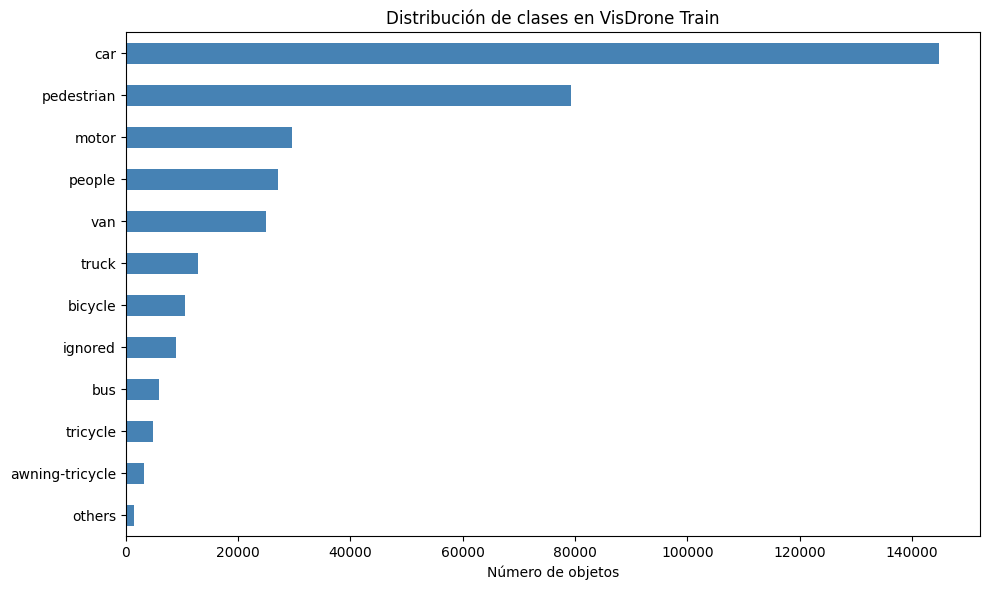

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
distribucion.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Distribución de clases en VisDrone Train')
ax.set_xlabel('Número de objetos')
plt.tight_layout()
plt.show()

La distribución de clases revela un claro desbalanceo en el dataset. La clase car domina ampliamente con más de 144k objetos, lo cual tiene sentido en un entorno urbano donde los coches son el elemento más frecuente. Le sigue pedestrian con 79k objetos, también esperado en escenas de ciudad.

En el extremo opuesto, clases como awning-tricycle, others y tricycle tienen menos de 5k objetos cada una, lo que puede dificultar que el modelo aprenda a detectarlas correctamente.

Este desbalanceo es un riesgo técnico importante. El modelo tenderá a detectar bien coches y peatones pero rendirá peor en las clases minoritarias. Durante el entrenamiento habrá que tenerlo en cuenta mediante técnicas como data augmentation selectivo.

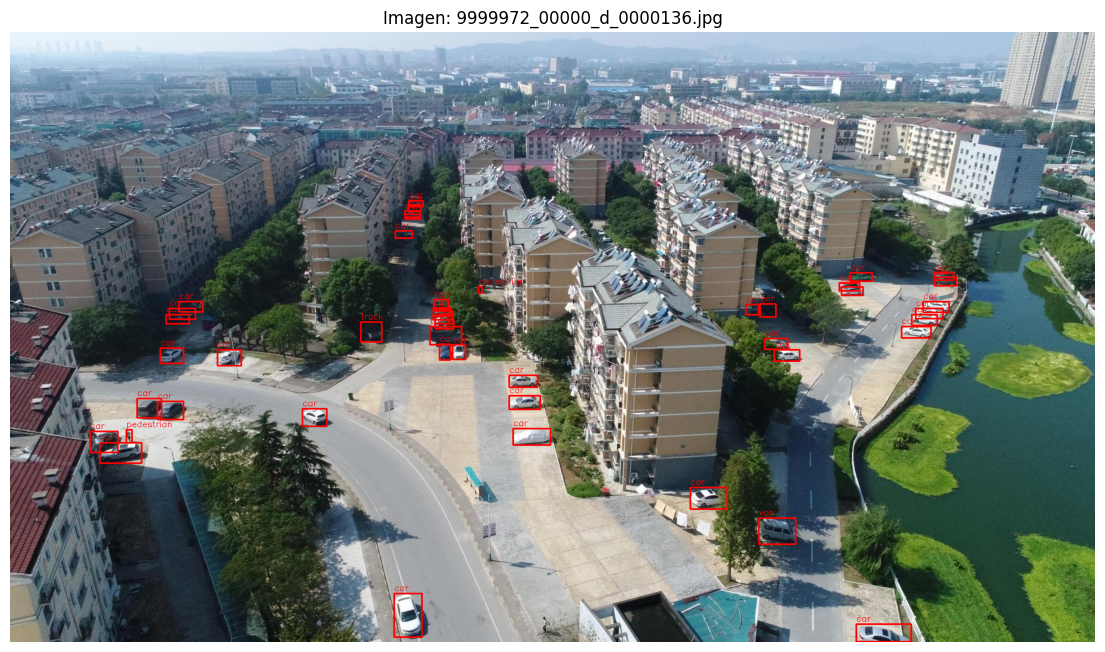

In [33]:
# primera imagen y su anotación correspondiente
imagenes_train = list((TRAIN_DIR / 'images').iterdir())
img_path = imagenes_train[0]
ann_path = TRAIN_DIR / 'annotations' / (img_path.stem + '.txt')

# imagen con OpenCV
img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# anotación
df_ann = pd.read_csv(ann_path, header=None,
                     names=['x', 'y', 'w', 'h', 'score', 'clase', 'truncation', 'occlusion'])

# bounding boxes
for _, row in df_ann.iterrows():
    x, y, w, h, clase = int(row.x), int(row.y), int(row.w), int(row.h), int(row.clase)
    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
    cv2.putText(img, clases[clase], (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)

plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis('off')
plt.title(f'Imagen: {img_path.name}')
plt.show()

Las imágenes de VisDrone están capturadas desde una perspectiva aérea elevada, lo que genera dos retos técnicos importantes. Primero, los objetos son muy pequeños en relación al tamaño total de la imagen. Los coches y peatones ocupan apenas unos pocos píxeles. Segundo, la densidad de objetos por imagen es alta, con múltiples instancias solapadas o muy próximas entre sí. Estos dos factores hacen que VisDrone sea un dataset técnicamente desafiante y un buen banco de pruebas real para YOLOv8.

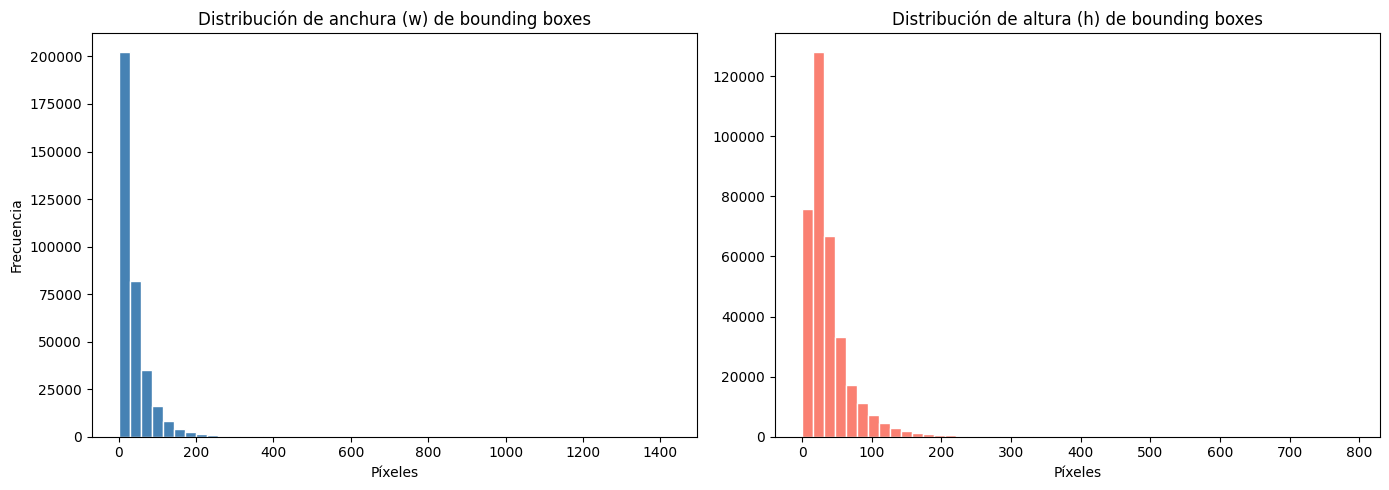

Anchura media: 39.1 px
Altura media: 37.5 px
Anchura máxima: 1424 px
Altura máxima: 790 px


In [ ]:
# tamaño de bounding boxes en train
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_total['w'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de anchura (w) de bounding boxes')
axes[0].set_xlabel('Píxeles')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df_total['h'], bins=50, color='salmon', edgecolor='white')
axes[1].set_title('Distribución de altura (h) de bounding boxes')
axes[1].set_xlabel('Píxeles')

plt.tight_layout()
plt.show()

print(f"Anchura media: {df_total['w'].mean():.1f} px")
print(f"Altura media: {df_total['h'].mean():.1f} px")
print(f"Anchura máxima: {df_total['w'].max()} px")
print(f"Altura máxima: {df_total['h'].max()} px")

La distribución de tamaños de los bounding boxes confirma que la gran mayoría de objetos son muy pequeños, con una media de 39x37 píxeles. La distribución está muy concentrada en valores bajos con una cola larga hacia la derecha. Hay algunos objetos grandes pero son la excepción. Esto supone un reto técnico importante para YOLOv8 ya que detectar objetos pequeños requiere que el modelo capture detalles finos en las feature maps de alta resolución. Los valores máximos de 1424x790 px corresponden probablemente a anotaciones de zonas ignoradas o vehículos muy cercanos a la cámara.

Media de objetos por imagen: 54.6
Máximo de objetos en una imagen: 914
Mínimo de objetos en una imagen: 1


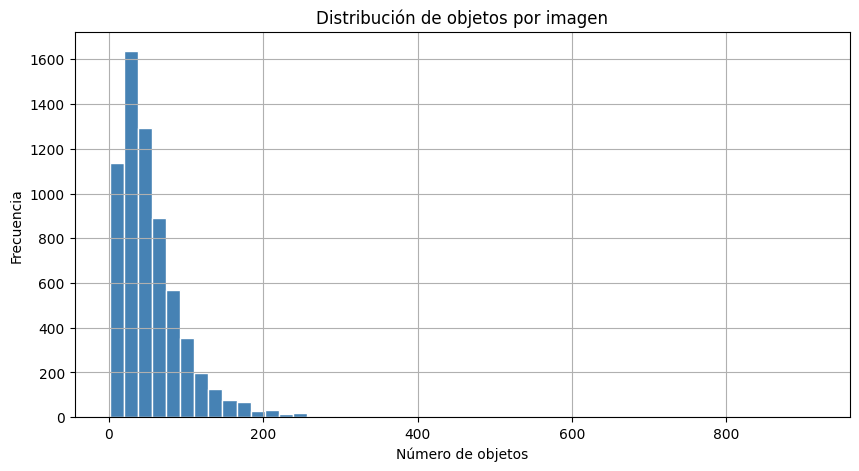

In [ ]:
objetos_por_imagen = df_total.groupby(df_total.index // len(df_total) * len(archivos)).size()

conteos = []
for archivo in archivos:
    df_temp = pd.read_csv(archivo, header=None,
                          names=['x', 'y', 'w', 'h', 'score', 'clase', 'truncation', 'occlusion'])
    conteos.append(len(df_temp))

conteos = pd.Series(conteos)
print(f"Media de objetos por imagen: {conteos.mean():.1f}")
print(f"Máximo de objetos en una imagen: {conteos.max()}")
print(f"Mínimo de objetos en una imagen: {conteos.min()}")

plt.figure(figsize=(10, 5))
conteos.hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Distribución de objetos por imagen')
plt.xlabel('Número de objetos')
plt.ylabel('Frecuencia')
plt.show()

El dataset tiene una media de 54.6 objetos por imagen, lo que indica una alta densidad de anotaciones. La distribución es asimétrica con cola larga. La mayoría de imágenes tienen entre 20 y 100 objetos, pero hay casos extremos con más de 900 objetos en una sola imagen. Esta densidad es otro reto técnico relevante ya que el modelo tendrá que manejar muchas detecciones simultáneas y gestionar correctamente el solapamiento entre bounding boxes mediante Non-Maximum Suppression (NMS).

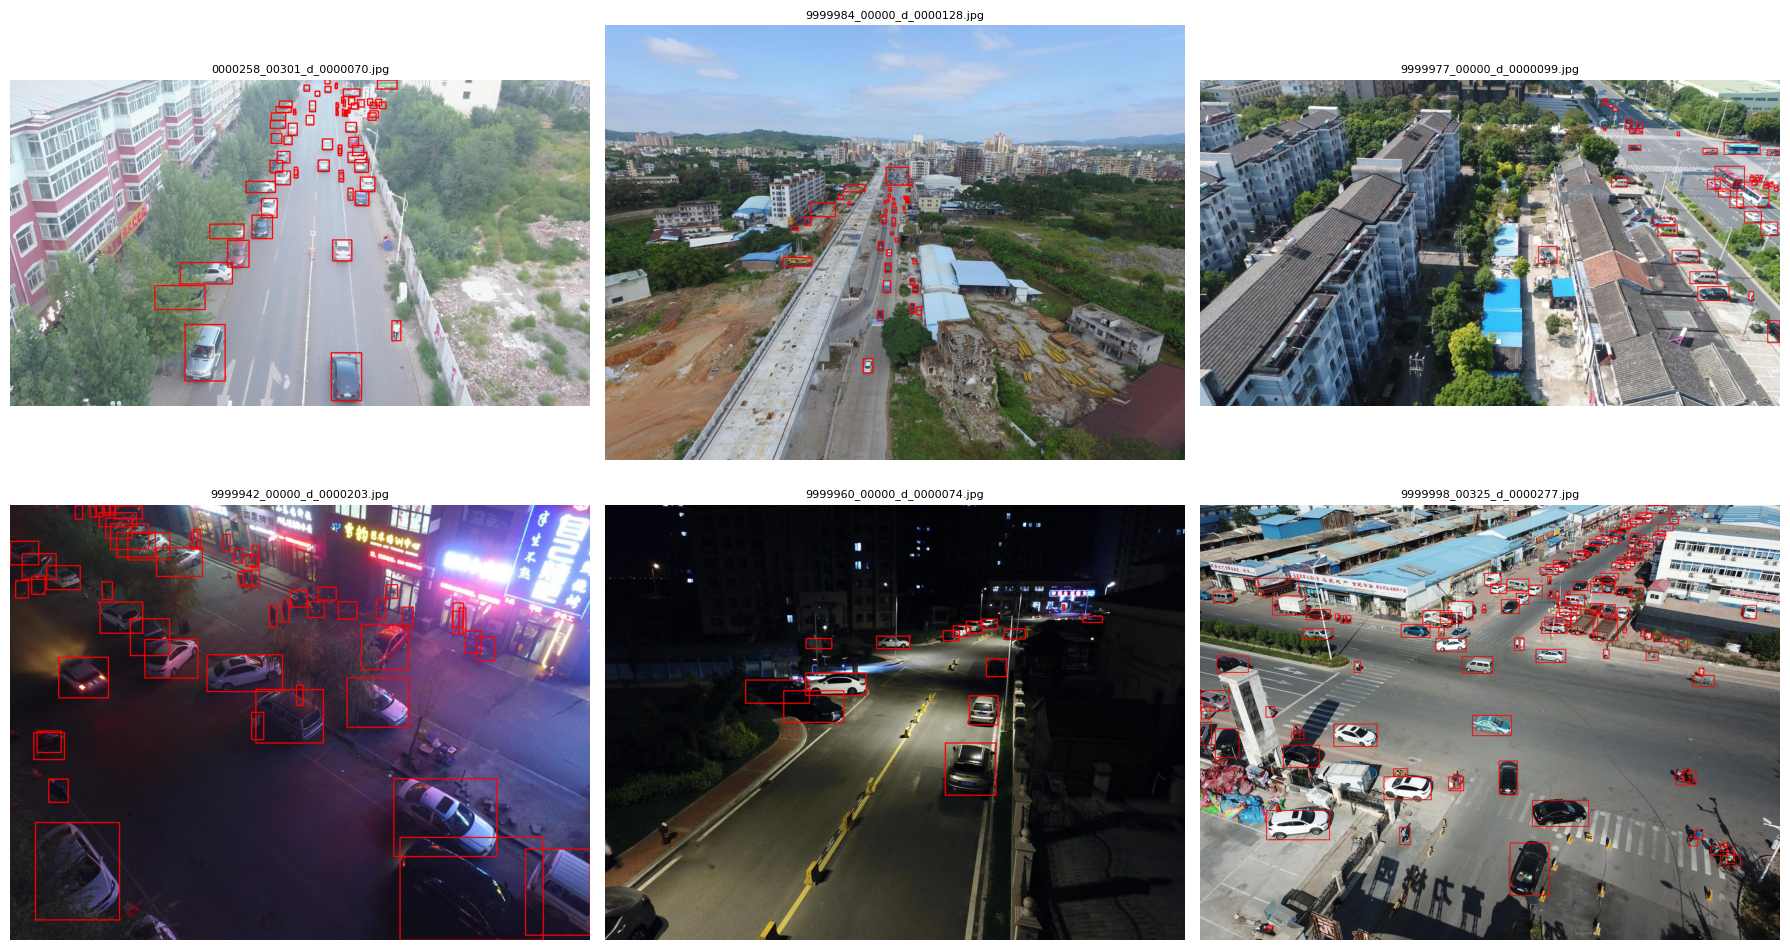

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

muestra = random.sample(imagenes_train, 6)

for i, img_path in enumerate(muestra):
    ann_path = TRAIN_DIR / 'annotations' / (img_path.stem + '.txt')
    
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    df_ann = pd.read_csv(ann_path, header=None,
                         names=['x', 'y', 'w', 'h', 'score', 'clase', 'truncation', 'occlusion'])
    
    for _, row in df_ann.iterrows():
        x, y, w, h = int(row.x), int(row.y), int(row.w), int(row.h)
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
    
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(img_path.name, fontsize=8)

plt.tight_layout()
plt.show()

La muestra aleatoria de imágenes revela la gran variedad del dataset. Se encuentran escenas diurnas y nocturnas, diferentes alturas de vuelo del dron, distintas densidades de tráfico y entornos variados como calles comerciales, carreteras y zonas residenciales. Esta variedad es positiva para la generalización del modelo, aunque también introduce retos adicionales como cambios de iluminación extremos. Especialmente en las escenas nocturnas y variaciones en el tamaño aparente de los objetos según la altura de captura.

Tras analizar el dataset VisDrone2019-DET podemos extraer las siguientes conclusiones clave que condicionarán el diseño del modelo:

- Tamaño del dataset: 6471 imágenes de train, 548 de validación y 1610 de test. Suficiente para entrenar un modelo robusto con fine-tuning.
- Desbalanceo de clases: car y pedestrian dominan ampliamente. Las clases minoritarias como awning-tricycle y others pueden ser problemáticas.
- Objetos pequeños: Media de 39x37 píxeles por bounding box. Reto principal del dataset.
- Alta densidad: Media de 54.6 objetos por imagen, con casos extremos de más de 900.
- Variedad visual: Escenas diurnas, nocturnas, distintas alturas y entornos urbanos diversos.

Estos factores guiarán las decisiones de preprocesado y entrenamiento en los siguientes notebooks.

### Preprocesado del Dataset VisDrone

VisDrone usa su propio formato de anotaciones (x, y, w, h, clase...) pero YOLOv8 necesita un formato específico diferente. En este notebook convertiremos las anotaciones al formato YOLO, filtraremos las clases que nos interesan y organizaremos el dataset en la estructura de carpetas que espera ultralytics para entrenar.

#### Filtrado de clases

De las 12 clases originales de VisDrone eliminamos dos:
- **clase 0 (ignored regions):** zonas que el anotador marcó explícitamente para ignorar, no son objetos reales
- **clase 11 (others):** objetos no identificados, demasiado ambiguos para entrenar

Nos quedamos con 10 clases relevantes para nuestro caso de uso de smart city:
pedestrian, people, bicycle, car, van, truck, tricycle, awning-tricycle, bus, motor

In [21]:
# nos interesan (eliminamos 0=ignored y 11=others)
CLASES_VISDRONE = {
    1: 'pedestrian',
    2: 'people', 
    3: 'bicycle',
    4: 'car',
    5: 'van',
    6: 'truck',
    7: 'tricycle',
    8: 'awning-tricycle',
    9: 'bus',
    10: 'motor'
}

# clases a índices 0-9 para YOLO
CLASE_REMAP = {k: i for i, k in enumerate(CLASES_VISDRONE.keys())}
print(CLASE_REMAP)

{1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9}


#### Conversión de formato VisDrone a formato YOLO

VisDrone y YOLOv8 usan formatos de anotación diferentes que hay que convertir.

**Formato VisDrone:**
x_min, y_min, w, h, score, clase, truncation, occlusion
- Las coordenadas son absolutas en píxeles
- x_min, y_min es la esquina superior izquierda del bounding box

**Formato YOLO:**
clase, x_center, y_center, w, h
- Todo está normalizado entre 0 y 1 respecto al tamaño de la imagen
- x_center, y_center es el centro del bounding box

**Conversión:**
- x_center = (x_min + w/2) / imagen_width
- y_center = (y_min + h/2) / imagen_height
- w = w / imagen_width
- h = h / imagen_height

In [2]:
def convertir_anotacion(ann_path, img_width, img_height):
    df = pd.read_csv(ann_path, header=None,
                     names=['x', 'y', 'w', 'h', 'score', 'clase', 'truncation', 'occlusion'])
    
    lineas_yolo = []
    for _, row in df.iterrows():
        clase = int(row.clase)
        
        #  clases 0 y 11 ignoradas
        if clase not in CLASES_VISDRONE:
            continue
        
        # formato YOLO como se explica
        x_center = (row.x + row.w / 2) / img_width
        y_center = (row.y + row.h / 2) / img_height
        w_norm = row.w / img_width
        h_norm = row.h / img_height
        
        clase_yolo = CLASE_REMAP[clase]
        lineas_yolo.append(f"{clase_yolo} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}")
    
    return lineas_yolo

#### Estructura de carpetas para YOLOv8

ultralytics espera una estructura específica de carpetas para poder leer los datos durante el entrenamiento. Para cada split (train, val, test) necesita dos carpetas separadas: una llamada `images` con las imágenes y otra llamada `labels` con los archivos de anotaciones en formato YOLO. Cada imagen debe tener su archivo `.txt` correspondiente con exactamente el mismo nombre en la carpeta `labels`.

In [6]:
def crear_estructura_yolo(output_dir):
    for split in ['train', 'val', 'test']:
        (output_dir / split / 'images').mkdir(parents=True, exist_ok=True)
        (output_dir / split / 'labels').mkdir(parents=True, exist_ok=True)
    print("Estructura de carpetas creada correctamente")

YOLO_DIR = DATA_DIR / 'visdrone_yolo'
crear_estructura_yolo(YOLO_DIR)

Estructura de carpetas creada correctamente


In [9]:
# bucle donde convertimos todas las anotaciones y copiamos las imagenes al nuevo directorio creado
splits = {
    'train': TRAIN_DIR,
    'val': VAL_DIR,
    'test': TEST_DIR
}

for split, src_dir in splits.items():
    imagenes = list((src_dir / 'images').iterdir())
    print(f"Procesando {split}: {len(imagenes)} imágenes...")
    
    for img_path in imagenes:
        # tamaño de imagen
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]
        
        # anotación con la función para convertir
        ann_path = src_dir / 'annotations' / (img_path.stem + '.txt')
        lineas_yolo = convertir_anotacion(ann_path, w, h)
        
        # label en formato YOLO
        label_out = YOLO_DIR / split / 'labels' / (img_path.stem + '.txt')
        with open(label_out, 'w') as f:
            f.write('\n'.join(lineas_yolo))
        
        #copiar imagen
        shutil.copy(img_path, YOLO_DIR / split / 'images' / img_path.name)
    
    print(f"{split} completado")

Procesando train: 6471 imágenes...
train completado
Procesando val: 548 imágenes...
val completado
Procesando test: 1610 imágenes...
test completado


#### Archivo de configuración data.yaml

ultralytics necesita un archivo de configuración llamado `data.yaml` que le indica dónde encontrar los datos y qué clases existen. Este archivo contiene las rutas a las carpetas de train, val y test, el número de clases (`nc`) y los nombres de cada clase en orden. Es el archivo que pasaremos al modelo en el momento del entrenamiento para que sepa cómo leer el dataset.

In [10]:
yaml_content = f"""
path: {YOLO_DIR.absolute()}
train: train/images
val: val/images
test: test/images

nc: 10
names: ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']
"""

with open(YOLO_DIR / 'data.yaml', 'w') as f:
    f.write(yaml_content)

print("data.yaml creado correctamente")

data.yaml creado correctamente


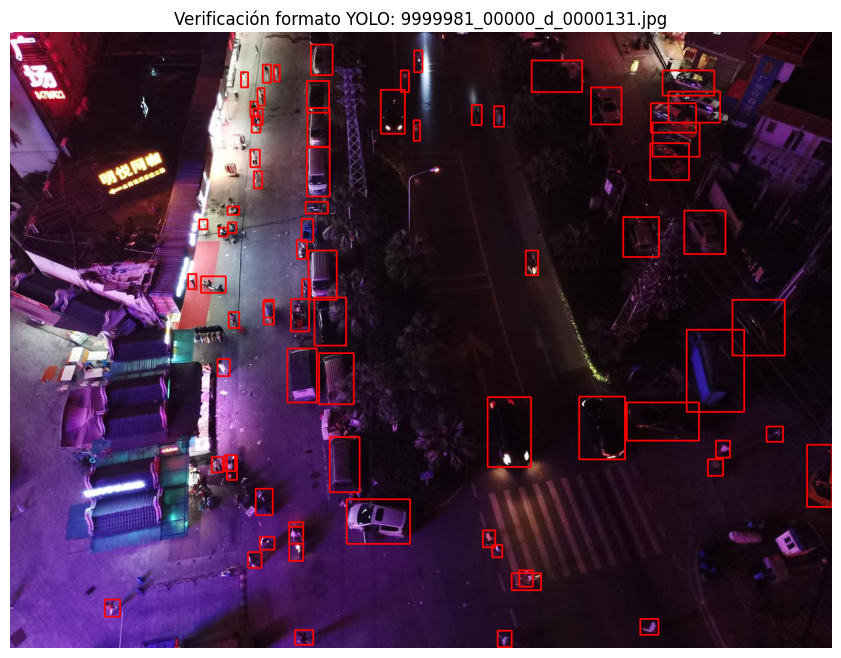

In [11]:
# comprobación de haber hecho todo como nos esperamos
imagenes_yolo = list((YOLO_DIR / 'train' / 'images').iterdir())
img_path = random.choice(imagenes_yolo)
label_path = YOLO_DIR / 'train' / 'labels' / (img_path.stem + '.txt')
img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

with open(label_path) as f:
    lineas = f.readlines()

for linea in lineas:
    vals = linea.strip().split()
    clase, x_c, y_c, bw, bh = int(vals[0]), float(vals[1]), float(vals[2]), float(vals[3]), float(vals[4])
    
    #desnormalizar
    x1 = int((x_c - bw/2) * w)
    y1 = int((y_c - bh/2) * h)
    x2 = int((x_c + bw/2) * w)
    y2 = int((y_c + bh/2) * h)
    
    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis('off')
plt.title(f'Verificación formato YOLO: {img_path.name}')
plt.show()

El dataset VisDrone ha sido convertido correctamente al formato YOLO. Se han realizado los siguientes pasos:

- Filtrado de las clases 0 (ignored) y 11 (others), quedándonos con 10 clases relevantes
- Conversión de coordenadas absolutas a coordenadas normalizadas centradas
- Reorganización de las carpetas en la estructura que espera ultralytics
- Generación del archivo data.yaml con la configuración del dataset

A priori, el dataset está listo para el entrenamiento.

### Modelo y Entrenamiento

En esta sección definimos la arquitectura YOLOv8, justificamos su elección y ejecutamos el entrenamiento sobre el dataset VisDrone preprocesado.

#### Arquitectura: YOLOv8

YOLOv8 es una CNN (Red Neuronal Convolucional) de la familia YOLO (You Only Look Once) desarrollada por Ultralytics. A diferencia de arquitecturas en dos etapas como Faster R-CNN vista en el tema 2 de la asignatura, YOLOv8 realiza la detección en una sola pasada por la red, lo que la hace especialmente adecuada para detección en tiempo real.

La arquitectura se compone de tres partes principales:
- **Backbone (CSPDarknet):** extrae las características visuales de la imagen a distintas escalas
- **Neck (FPN + PAN):** combina las características de distintas escalas para detectar objetos grandes y pequeños
- **Head:** predice las bounding boxes, las clases y las puntuaciones de confianza

Usamos la variante **YOLOv8n** (nano). Esta es la más ligera de la familia, porque nos permite entrenar y hacer inferencia rápidamente manteniendo una precisión competitiva. Además aprovechamos los pesos preentrenados en ImageNet mediante transfer learning, lo que es especialmente útil dado el reto que supone VisDrone.

El entrenamiento se realiza con PyTorch como framework base, pero a través de la librería ultralytics que proporciona una API de alto nivel para trabajar con YOLOv8. Esto nos permite centrarnos en la configuración del modelo y el análisis de resultados sin tener que implementar el bucle de entrenamiento manualmente.

```
Imagen de entrada
      ↓
┌─────────────────┐
│   BACKBONE      │
│  CSPDarknet     │  → Extrae características a múltiples escalas
└─────────────────┘
      ↓
┌─────────────────┐
│     NECK        │
│   FPN + PAN     │  → Combina escalas para objetos grandes y pequeños
└─────────────────┘
      ↓
┌─────────────────┐
│     HEAD        │
│  Detección      │  → Predice bounding boxes, clases y confianza
└─────────────────┘
      ↓
Predicciones finales (clase, bbox, confianza)
```

#### Pipeline de entrenamiento

El entrenamiento de YOLOv8 sigue un ciclo estándar de deep learning. En cada época la imagen pasa por el backbone que extrae características visuales, el neck las combina a distintas escalas y la cabeza predice los bounding boxes y clases. La loss es una combinación de tres términos: box loss (calidad del bounding box), cls loss (clasificación) y dfl loss (distribución de la localización). El optimizador AdamW ajusta los pesos en cada iteración para minimizar esta loss. Al final de cada época se evalúa el modelo sobre validación y se calcula el mAP@0.5.


```
Época N
   ↓
┌─────────────────────────────────────┐
│           FORWARD PASS              │
│  Imagen → Backbone → Neck → Head   │
│         Predicciones                │
└─────────────────────────────────────┘
   ↓
┌─────────────────────────────────────┐
│          CÁLCULO DE LOSS            │
│  box_loss + cls_loss + dfl_loss     │
└─────────────────────────────────────┘
   ↓
┌─────────────────────────────────────┐
│          BACKWARD PASS              │
│  Gradientes → AdamW → actualiza     │
│            pesos                    │
└─────────────────────────────────────┘
   ↓
┌─────────────────────────────────────┐
│           VALIDACIÓN                │
│      mAP@0.5 sobre val set          │
└─────────────────────────────────────┘
   ↓
Época N+1

```
Los hiperparámetros clave son: número de épocas, tamaño de imagen, batch size y learning rate inicial.

**Carga del modelo**

In [ ]:
model = YOLO('yolov8n.pt')

print(model.info())

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs
(129, 3157200, 0, 8.8575488)


Al cargar YOLOv8n obtenemos un resumen de la arquitectura:

- **129 capas:** el número total de capas de la red entre backbone, neck y head
- **3.157.200 parámetros:** los pesos que el modelo tiene que aprender durante el entrenamiento. Es una cantidad relativamente pequeña, ya que modelos más grandes como YOLOv8x tienen 68M de parámetros
- **0 gradientes:** antes de entrenar los gradientes son cero, se calcularán durante el backward pass como se comentó.
- **8.9 GFLOPs:** operaciones de punto flotante necesarias para procesar una imagen. Indica el coste computacional de una inferencia. Cuanto menor, más rápido en tiempo real

Estos valores confirman que YOLOv8n es un modelo ligero y eficiente, ideal para un sistema de vigilancia que necesita procesar vídeo en tiempo real.

**Hiperparámetros de entrenamiento**

- **epochs=50:** número de veces que el modelo ve el dataset completo. 50 épocas es un balance razonable entre tiempo de entrenamiento y convergencia para un prototipo.

- **imgsz=640:** tamaño al que se redimensionan todas las imágenes antes de entrar a la red. 640px es el tamaño estándar de YOLOv8 y un buen balance entre detalle y coste computacional. Importante para VisDrone donde los objetos son pequeños.

- **batch=16:** número de imágenes procesadas simultáneamente en cada iteración. Con 7.5GB de VRAM en nuestro caso, batch=16 es seguro sin saturar la memoria.

- **lr0=0.01:** learning rate inicial. Controla el tamaño del paso del optimizador AdamW en cada actualización de pesos. ultralytics aplica cosine decay automáticamente para ir reduciéndolo a lo largo del entrenamiento.

- **device=0:** usa la GPU 0 (nuestra RTX 5060) en lugar de CPU.

In [18]:
print(str(YOLO_DIR / 'data.yaml')) # información de los datos

../data/visdrone_yolo/data.yaml


##### Modelo 1

In [19]:
results = model.train(
    data=str(YOLO_DIR / 'data.yaml'),
    epochs=50,
    imgsz=640,
    batch=16,
    lr0=0.01,
    device=0,
    project='../models',
    name='visdrone_yolov8n',
    exist_ok=True
)

Ultralytics 8.4.47 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/visdrone_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=visdrone_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

El modelo completó 50 épocas en 0.793 horas. Los resultados finales sobre el conjunto de validación son:

- **mAP@0.5 general: 0.298** — el modelo detecta correctamente casi un 30% de los objetos con un umbral de IoU de 0.5
- **mAP@0.5-0.95: 0.167** — métrica más estricta que evalúa a múltiples umbrales de IoU

Por clases destacan:
- **car (0.723):** la clase más representada y mejor detectada
- **bus (0.405) y van (0.340):** resultados razonables
- **bicycle (0.066) y awning-tricycle (0.102):** clases minoritarias con peor rendimiento, confirmando el problema del desbalanceo identificado en la exploración

Esto es coherente con lo esperado, ya que las clases con más ejemplos en train se detectan mejor.

In [21]:
results_dir = Path('../notebooks/runs/models/visdrone_yolov8n')
print(list(results_dir.iterdir()))

[PosixPath('../notebooks/runs/models/visdrone_yolov8n/results.png'), PosixPath('../notebooks/runs/models/visdrone_yolov8n/val_batch2_pred.jpg'), PosixPath('../notebooks/runs/models/visdrone_yolov8n/train_batch16201.jpg'), PosixPath('../notebooks/runs/models/visdrone_yolov8n/train_batch2.jpg'), PosixPath('../notebooks/runs/models/visdrone_yolov8n/results.csv'), PosixPath('../notebooks/runs/models/visdrone_yolov8n/BoxF1_curve.png'), PosixPath('../notebooks/runs/models/visdrone_yolov8n/val_batch0_pred.jpg'), PosixPath('../notebooks/runs/models/visdrone_yolov8n/train_batch0.jpg'), PosixPath('../notebooks/runs/models/visdrone_yolov8n/val_batch2_labels.jpg'), PosixPath('../notebooks/runs/models/visdrone_yolov8n/labels.jpg'), PosixPath('../notebooks/runs/models/visdrone_yolov8n/train_batch16202.jpg'), PosixPath('../notebooks/runs/models/visdrone_yolov8n/BoxPR_curve.png'), PosixPath('../notebooks/runs/models/visdrone_yolov8n/train_batch1.jpg'), PosixPath('../notebooks/runs/models/visdrone_yolo

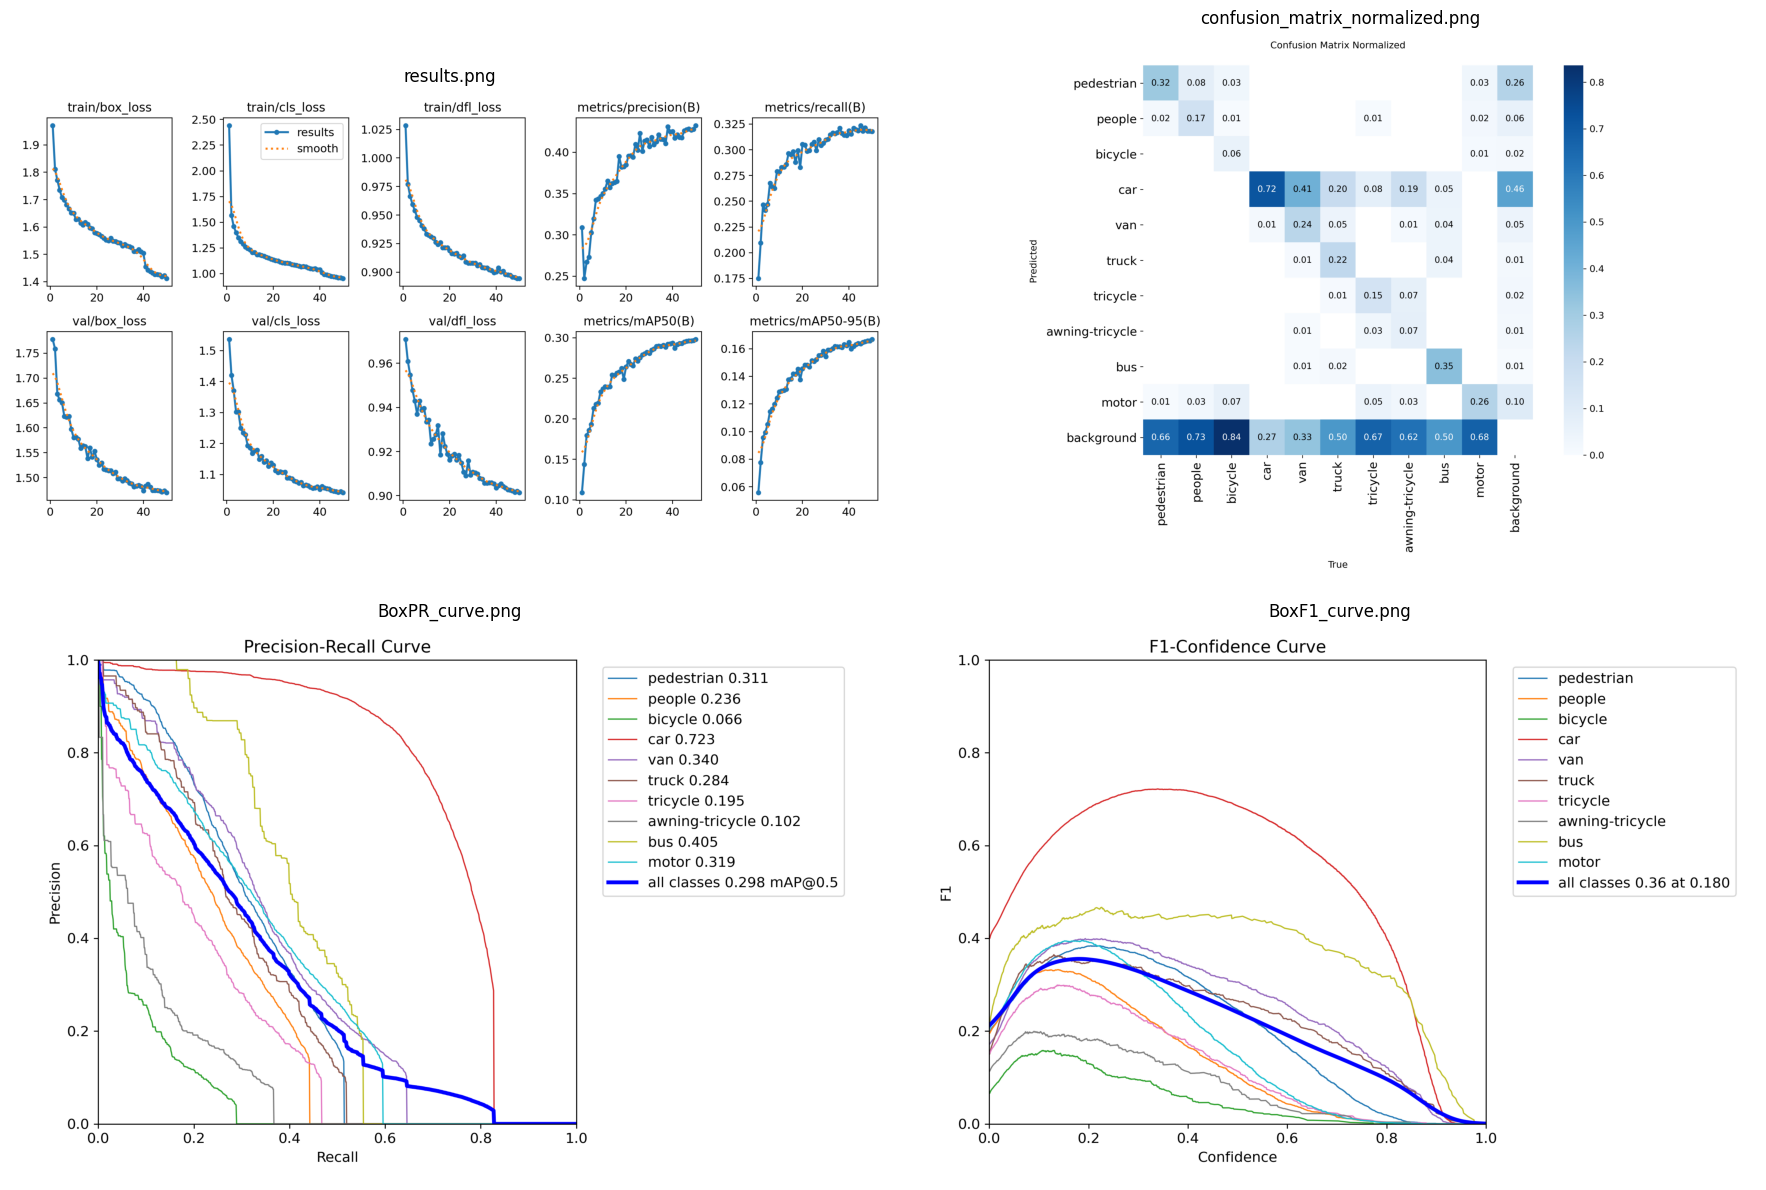

In [22]:
imagenes = ['results.png', 'confusion_matrix_normalized.png', 
            'BoxPR_curve.png', 'BoxF1_curve.png']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, nombre in enumerate(imagenes):
    img = Image.open(results_dir / nombre)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(nombre)

plt.tight_layout()
plt.show()

**Curvas de loss:** Tanto la loss de train como la de validación descienden de forma consistente a lo largo de las 50 épocas sin signos de overfitting. Ambas curvas bajan juntas, lo que indica que el modelo generaliza bien.

**mAP:** El mAP@0.5 sube progresivamente de 0.109 en la época 1 hasta 0.298 en la época 50, con margen de mejora si se entrenara más épocas o con un modelo más grande.

**Precision-Recall:** Car destaca muy por encima del resto con un mAP de 0.723. Bicycle y awning-tricycle tienen curvas muy bajas, confirmando el problema del desbalanceo de clases. El F1 óptimo global se sitúa en 0.36 con un umbral de confianza de 0.18.

**Matriz de confusión:** El modelo confunde frecuentemente los objetos con background — especialmente en clases pequeñas como bicycle y tricycle. Car es la clase mejor discriminada con un 0.72 en la diagonal. El alto porcentaje de background en todas las clases es típico de VisDrone por la pequeñez de los objetos.

In [23]:
model_best = YOLO('../notebooks/runs/models/visdrone_yolov8n/weights/best.pt')

metrics = model_best.val(
    data=str(YOLO_DIR / 'data.yaml'),
    split='test'
)

Ultralytics 8.4.47 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 215.0±56.1 MB/s, size: 199.2 KB)
val: Scanning /home/salmags/Documentos/master_IA/deep_learning/urban-vision-dl/data/visdrone_yolo/test/labels... 1610 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1610/1610 1.6Kit/s 1.0s0.1s
val: New cache created: /home/salmags/Documentos/master_IA/deep_learning/urban-vision-dl/data/visdrone_yolo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 10.5it/s 9.6s.1s
                   all       1610      75102      0.384      0.286      0.249      0.137
            pedestrian       1197      21006      0.396      0.228      0.197     0.0731
                people        797       6376      0.442     0.0965      0.102     0.0318
      


El modelo obtiene un mAP@0.5 de 0.249 sobre el test set, ligeramente inferior al 0.298 de validación, lo que confirma que el modelo generaliza correctamente sin overfitting.

Por clases el comportamiento es consistente con validación:
- **car (0.644) y bus (0.479):** mejor rendimiento, objetos más grandes y bien representados
- **bicycle (0.053) y tricycle (0.122):** peor rendimiento, clases minoritarias y objetos muy pequeños
- **Velocidad de inferencia: 1.6ms por imagen** — suficientemente rápido para aplicaciones en tiempo real

Estos resultados constituyen la baseline del proyecto. A continuación exploraremos mejoras.


##### Modelo 2

El modelo v1 obtuvo un mAP@0.5 de 0.249 en test, un resultado razonable para VisDrone pero con margen de mejora. La limitación principal de YOLOv8n es su capacidad. Con solo 3M de parámetros, la red puede no tener suficiente capacidad para aprender a distinguir las 10 clases en escenas tan densas y con objetos tan pequeños.

Para mejorar esto entrenamos YOLOv8s, la versión small de la familia, con 11M de parámetros. Mantenemos el mismo imgsz=640 para no tener problemas de VRAM, pero añadimos early stopping con patience=15 para dejar que el modelo converja de forma óptima sin sobreentrenar.

El objetivo es comprobar si una arquitectura más grande mejora significativamente los resultados manteniendo las mismas condiciones de datos y resolución.

In [26]:
model_v2 = YOLO('yolov8s.pt')

results_v2 = model_v2.train(
    data=str(YOLO_DIR / 'data.yaml'),
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    patience=15,
    project='../notebooks/runs/models',
    name='visdrone_yolov8s_640',
    exist_ok=True
)

Ultralytics 8.4.47 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/visdrone_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=visdrone_yolov8s_640, nbs=64, nms=False, opset=None, optimize=False, optimizer=

El entrenamiento completó 93 épocas de las 100 planificadas. El early stopping detuvo el proceso al detectar que el mAP no mejoraba en las últimas 15 épocas consecutivas, siendo la época 78 la que produjo el mejor modelo.

Esto es una señal positiva, ya que el modelo encontró su punto óptimo sin necesidad de llegar al límite de épocas y sin sobreentrenar.

Los resultados sobre validación del mejor modelo son:

- **mAP@0.5: 0.396** — mejora significativa respecto al 0.298 del modelo v1
- **car: 0.789** — excelente detección de la clase más representada
- **bus: 0.575** — buena mejora respecto al 0.405 del v1
- **pedestrian: 0.433** — mejora notable respecto al 0.311 del v1
- **bicycle: 0.136** — sigue siendo la clase más difícil pero mejora del 0.066 del v1

El modelo ocupa 22.5MB en disco, frente a los 6.2MB del v1 -> un coste razonable por la ganancia de rendimiento obtenida.

In [7]:
model_v2_best = YOLO('../notebooks/runs/notebooks/runs/models/visdrone_yolov8s_640/weights/best.pt')

metrics_v2 = model_v2_best.val(
    data=str(YOLO_DIR / 'data.yaml'),
    split='test'
)

Ultralytics 8.4.47 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 175.1±44.2 MB/s, size: 165.5 KB)
val: Scanning /home/salmags/Documentos/master_IA/deep_learning/urban-vision-dl/data/visdrone_yolo/test/labels.cache... 1610 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1610/1610 482.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 4.6it/s 21.9s0.2s
                   all       1610      75102      0.466      0.347      0.318      0.181
            pedestrian       1197      21006      0.489      0.293      0.278      0.109
                people        797       6376      0.526      0.131      0.146     0.0469
               bicycle        377       1302      0.296      0.118        0.1     0.0398
                   car       1530   

La evaluación sobre el conjunto de test confirma que el modelo generaliza correctamente:

- **mAP@0.5: 0.318** sobre 1610 imágenes y 75.102 objetos nunca vistos durante el entrenamiento
- La diferencia entre validación (0.396) y test (0.318) es esperable y no indica overfitting. Simplemente el test set es más grande y variado
- **Velocidad de inferencia: 4.1ms por imagen** , es perfectamente válido para aplicaciones de vigilancia en tiempo real

Por clases destacan:
- **car (0.724) y bus (0.549):** clases grandes y bien representadas, detección robusta
- **pedestrian (0.278):** resultado razonable dado el tamaño pequeño de las personas en imágenes aéreas
- **bicycle (0.100) y people (0.146):** clases minoritarias y visualmente ambiguas, siguen siendo el mayor reto

Estos resultados son coherentes con el estado del arte en VisDrone investigado.

##### Modelo 3 

Tras confirmar que YOLOv8s supera a YOLOv8n en capacidad, exploramos si es posible mejorar YOLOv8n ajustando sus hiperparámetros de entrenamiento en lugar de aumentar el tamaño del modelo.

Los cambios respecto al v1 son:
- **lr0=0.001** en lugar de 0.01 — un learning rate más bajo y conservador para que el optimizador dé pasos más pequeños y afine mejor los pesos
- **weight_decay=0.001** en lugar de 0.0005 — más regularización para penalizar pesos grandes y reducir el riesgo de overfitting
- **epochs=150 con patience=20** — más tiempo para converger con una ventana de early stopping más amplia

El objetivo es comprobar si un entrenamiento más cuidadoso puede compensar la menor capacidad de YOLOv8n frente a YOLOv8s.

In [ ]:
model_v3 = YOLO('yolov8n.pt')

results_v3 = model_v3.train(
    data=str(YOLO_DIR / 'data.yaml'),
    epochs=150,
    imgsz=640,
    batch=16,
    device=0,
    patience=20,
    lr0=0.001,
    weight_decay=0.001,
    project='../notebooks/runs/models',
    name='visdrone_yolov8n_tuned',
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.48 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.47 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/visdrone_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0,

El modelo completó 145 épocas con un mAP@0.5 de 0.335 en validación. A diferencia del v2 que paró en la época 93 con early stopping, el v3 siguió entrenando hasta casi el límite sin encontrar una mejora significativa. Esto es una señal de que el modelo ha llegado a su techo de capacidad.

El ajuste de hiperparámetros no fue suficiente para compensar la limitación arquitectónica de YOLOv8n. Con solo 3M de parámetros, el modelo no tiene suficiente capacidad para aprender las representaciones necesarias para distinguir las 10 clases en escenas tan densas, independientemente de cómo se configure el entrenamiento.

**Conclusión: el v3 (mAP@0.5 0.335) no supera al v2 (mAP@0.5 0.396). El tamaño de la arquitectura importa más que el ajuste de hiperparámetros cuando el modelo es el cuello de botella.**

In [10]:
model_v3_best = YOLO('../notebooks/runs/notebooks/runs/models/visdrone_yolov8n_tuned/weights/best.pt')

metrics_v3 = model_v3_best.val(
    data=str(YOLO_DIR / 'data.yaml'),
    split='test'
)

Ultralytics 8.4.47 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4558.6±1092.6 MB/s, size: 211.1 KB)
val: Scanning /home/salmags/Documentos/master_IA/deep_learning/urban-vision-dl/data/visdrone_yolo/test/labels.cache... 1610 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1610/1610 675.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 10.7it/s 9.4s0.1s
                   all       1610      75102      0.412      0.311      0.275      0.153
            pedestrian       1197      21006      0.433      0.252      0.228     0.0856
                people        797       6376      0.468      0.115      0.121      0.038
               bicycle        377       1302       0.23     0.0768     0.0564     0.0207
                   car       1530  

| Modelo | Arquitectura | Épocas | mAP@0.5 test | mAP@0.5-95 test |
|--------|-------------|--------|-------------|----------------|
| v1 | YOLOv8n | 50 | 0.249 | 0.137 |
| v2 | YOLOv8s | 93 (early stop) | 0.318 | 0.181 |
| v3 | YOLOv8n tuned | 145 | 0.275 | 0.153 |

El modelo v3 mejora ligeramente al v1 (0.275 vs 0.249) gracias al ajuste de hiperparámetros, pero no alcanza al v2 (0.318). Esto confirma que el factor más determinante en este experimento fue el tamaño de la arquitectura, no la configuración del entrenamiento.

**El modelo v2 (YOLOv8s) es el ganador en este caso**

#####  Inferencia mejorada con SAHI -> modelo v2

Hasta ahora hemos evaluado el modelo v2 con inferencia estándar: la imagen completa entra a la red redimensionada a 640x640. El problema es que los objetos pequeños de VisDrone (media de 39x37 píxeles) pierden detalle al redimensionarse y el modelo no los detecta bien.

Para mejorar esto aplicamos **SAHI (Sliced Inference for High-resolution Images)**, una técnica que divide cada imagen en tiles solapados de 640x640, ejecuta el modelo sobre cada tile por separado y fusiona todas las predicciones en una detección final. El efecto es equivalente a hacer zoom en cada zona de la imagen antes de detectar, sin necesitar reentrenar el modelo ni más VRAM.

Aplicaremos SAHI sobre el modelo v2 (YOLOv8s) y compararemos los resultados visualmente con la inferencia estándar para demostrar la mejora en detección de objetos pequeños como peatones, bicicletas y motos. Comenzamos con un mini-ejemplo:

In [ ]:
# modelo q se va a usar
detection_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path='../notebooks/runs/notebooks/runs/models/visdrone_yolov8s_640/weights/best.pt',
    confidence_threshold=0.3,
    device='cuda:0'
)

In [ ]:
# Cogemos una imagen de test
imagenes_test = list((YOLO_DIR / 'test' / 'images').iterdir())
img_path = str(imagenes_test[0])

# inferencia normal con modelo v2 como siempre
result_standard = model_v2_best.predict(img_path, conf=0.3)

# inferencia con SAHI zoom
result_sahi = get_sliced_prediction(
    img_path,
    detection_model,
    slice_height=640,
    slice_width=640,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2
)

print(f"Detecciones estándar: {len(result_standard[0].boxes)}")
print(f"Detecciones SAHI: {len(result_sahi.object_prediction_list)}")


image 1/1 /home/salmags/Documentos/master_IA/deep_learning/urban-vision-dl/notebooks/../data/visdrone_yolo/test/images/9999938_00000_d_0000484.jpg: 384x640 17 cars, 1 truck, 2 buss, 27.9ms
Speed: 2.3ms preprocess, 27.9ms inference, 3.3ms postprocess per image at shape (1, 3, 384, 640)
Performing prediction on 6 slices.
Detecciones estándar: 20
Detecciones SAHI: 23


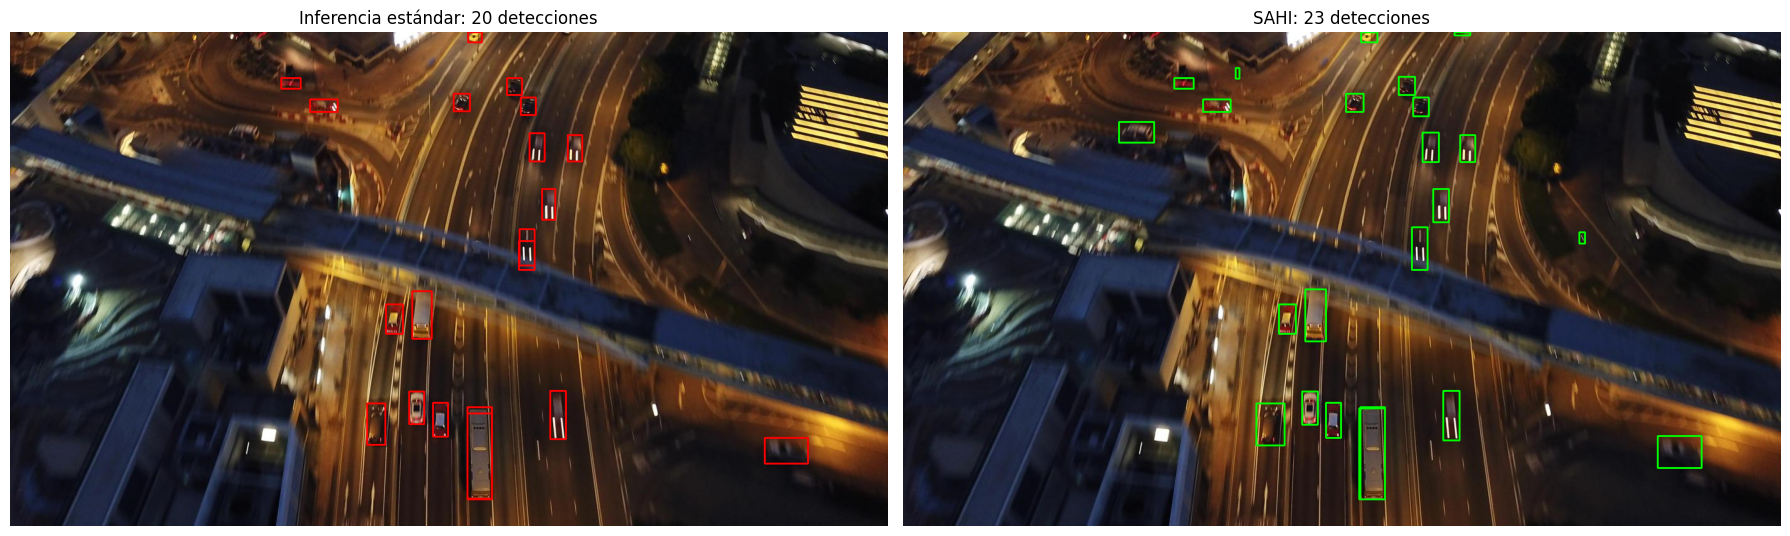

In [ ]:
%matplotlib inline
#visualización inferencia estándar
img_standard = cv2.imread(img_path)
img_standard = cv2.cvtColor(img_standard, cv2.COLOR_BGR2RGB)

for box in result_standard[0].boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cls = int(box.cls[0])
    cv2.rectangle(img_standard, (x1, y1), (x2, y2), (255, 0, 0), 2)

#visualización SAHI
img_sahi = cv2.imread(img_path)
img_sahi = cv2.cvtColor(img_sahi, cv2.COLOR_BGR2RGB)

for pred in result_sahi.object_prediction_list:
    bbox = pred.bbox
    x1, y1, x2, y2 = int(bbox.minx), int(bbox.miny), int(bbox.maxx), int(bbox.maxy)
    cv2.rectangle(img_sahi, (x1, y1), (x2, y2), (0, 255, 0), 2)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(img_standard)
axes[0].set_title(f'Inferencia estándar: {len(result_standard[0].boxes)} detecciones')
axes[0].axis('off')
axes[1].imshow(img_sahi)
axes[1].set_title(f'SAHI: {len(result_sahi.object_prediction_list)} detecciones')
axes[1].axis('off')
plt.tight_layout()
plt.show()

La comparativa visual confirma la utilidad de SAHI para VisDrone. Con inferencia estándar el modelo detecta 20 objetos, mientras que con SAHI detecta 23. Literalmente un 15% más de detecciones en esta imagen.

Las detecciones adicionales corresponden principalmente a vehículos pequeños en los bordes y zonas de menor resolución aparente de la imagen, exactamente donde la inferencia estándar falla por la pérdida de detalle al redimensionar a 640x640.

El coste de esta mejora es el tiempo de inferencia, SAHI divide la imagen en 6 tiles y procesa cada uno por separado, lo que multiplica el tiempo de cómputo. Para aplicaciones en tiempo real habría que evaluar el balance entre precisión y velocidad según los requisitos del sistema.

**Evaluación de SAHI sobre el test set completo**

Para cuantificar el impacto de SAHI más allá de ejemplos visuales, aplicamos la inferencia por tiles sobre las 1610 imágenes del test set completo.

El código hace lo siguiente:

- **`test_images`:** lista todas las imágenes del test set
- **`get_sliced_prediction`:** aplica SAHI sobre cada imagen — la divide en tiles de 640x640 con un solapamiento del 20% en ambas dimensiones, ejecuta el modelo v2 sobre cada tile y fusiona todas las predicciones
- **`overlap_height_ratio=0.2` y `overlap_width_ratio=0.2`:** el 20% de solapamiento garantiza que los objetos en los bordes de un tile aparezcan también en el tile adyacente y no se pierdan
- **`all_predictions`:** guarda para cada imagen el nombre y el número de detecciones encontradas
- Al final calculamos la media de detecciones por imagen con SAHI para compararla con la inferencia estándar

El objetivo es demostrar que SAHI detecta consistentemente más objetos que la inferencia estándar, especialmente en las clases minoritarias y de tamaño pequeño.

In [ ]:
test_images = list((YOLO_DIR / 'test' / 'images').iterdir())

all_predictions = []

for img_path in tqdm(test_images):
    result = get_sliced_prediction(
        str(img_path),
        detection_model,
        slice_height=640,
        slice_width=640,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2,
        verbose=0
    )
    all_predictions.append({
        'image': img_path.name,
        'n_detections': len(result.object_prediction_list)
    })

print(f"Total imágenes procesadas: {len(all_predictions)}")
print(f"Media de detecciones por imagen: {sum([p['n_detections'] for p in all_predictions]) / len(all_predictions):.1f}")

100%|██████████| 1610/1610 [02:46<00:00,  9.69it/s]

Total imágenes procesadas: 1610
Media de detecciones por imagen: 46.2


In [ ]:
conteo_standard = []
for img_path in tqdm(test_images):
    result = model_v2_best.predict(str(img_path), conf=0.3, verbose=False)
    conteo_standard.append(len(result[0].boxes))

print(f"Media detecciones estándar: {sum(conteo_standard)/len(conteo_standard):.1f}")
print(f"Media detecciones SAHI: 46.2")

100%|██████████| 1610/1610 [00:15<00:00, 102.99it/s]

Media detecciones estándar: 29.3
Media detecciones SAHI: 46.2


La evaluación sobre las 1610 imágenes del test set confirma el impacto significativo de SAHI:

| Método | Media detecciones por imagen |
|--------|---------------------------|
| Inferencia estándar (v2) | 29.3 |
| SAHI (v2) | 46.2 |
| Ground truth | 54.6 |

SAHI detecta un **58% más de objetos** que la inferencia estándar, acercándose mucho más al ground truth de 54.6 objetos por imagen. La brecha que queda entre SAHI (46.2) y el ground truth (54.6) corresponde principalmente a objetos extremadamente pequeños o parcialmente ocultos que ni siquiera con tiles de 640px son detectables.

Este resultado demuestra que SAHI es una mejora real y significativa para datasets con objetos pequeños como VisDrone.

##### Ampliación del dataset: car+person desde cámara a nivel de calle

Los tres modelos entrenados hasta ahora se basan exclusivamente en VisDrone. Estas son mágenes capturadas desde drones a vista aérea. Esto significa que el modelo ha aprendido a detectar objetos desde una perspectiva muy específica: vista de pájaro, objetos pequeños, alta densidad.

Un sistema de vigilancia urbana real combina cámaras a distintas alturas: drones, cámaras elevadas y cámaras a nivel de calle. Para que el modelo funcione bien en todas estas perspectivas necesita haber visto imágenes desde distintos puntos de vista durante el entrenamiento.

Por eso añadimos el dataset car+person. Son 3.526 imágenes capturadas desde cámaras a nivel de calle con las clases car y person etiquetadas. Al combinar VisDrone con este dataset, el modelo aprenderá a detectar coches y personas tanto desde vista aérea como desde perspectiva de calle, mejorando su capacidad de generalización para un despliegue real en smart city.

El modelo resultante será entrenado sobre el dataset combinado y comparado con el modelo v2 para evaluar si la diversidad de perspectivas mejora el rendimiento.

**Remapeo de clases**

El dataset car+person usa índices de clase distintos a VisDrone:
- car+person: `0=car`, `1=person`
- VisDrone: `0=pedestrian`, `3=car`

Antes de mezclar los datasets hay que convertir los labels de car+person para que usen los mismos índices que VisDrone. Sin este paso el modelo aprendería que car es la clase 0 en unas imágenes y la clase 3 en otras, lo que generaría predicciones incorrectas.

El remapeo es: car+person clase 0 → VisDrone clase 3, car+person clase 1 → VisDrone clase 0.

In [30]:
car_person_dir = DATA_DIR / 'car-person.yolov8'
for item in car_person_dir.iterdir():
    print(item)

../data/car-person.yolov8/data.yaml
../data/car-person.yolov8/train
../data/car-person.yolov8/README.roboflow.txt


In [31]:
car_person_images = list((car_person_dir / 'train' / 'images').iterdir())
car_person_labels = list((car_person_dir / 'train' / 'labels').iterdir())
print(f"Imágenes: {len(car_person_images)}")
print(f"Labels: {len(car_person_labels)}")

Imágenes: 3526
Labels: 3526


In [32]:
# ver un label de ejemplo
with open(car_person_labels[0]) as f:
    print(f.read())

1 0.3287760416666667 0.7916666666666666 0.055989583333333336 0.21296296296296297
1 0.7356770833333334 0.6469907407407407 0.049479166666666664 0.20601851851851852
1 0.7096354166666666 0.5393518518518519 0.046875 0.2175925925925926
1 0.6529947916666666 0.1087962962962963 0.048177083333333336 0.12962962962962962
1 0.654296875 0.04976851851851852 0.05078125 0.09953703703703703
1 0.3723958333333333 0.2569444444444444 0.049479166666666664 0.125
1 0.5026041666666666 0.24305555555555555 0.0390625 0.17592592592592593
1 0.4739583333333333 0.2361111111111111 0.046875 0.1712962962962963
1 0.4388020833333333 0.2175925925925926 0.046875 0.1712962962962963
1 0.4348958333333333 0.3819444444444444 0.049479166666666664 0.19907407407407407
1 0.4186197916666667 0.3229166666666667 0.04296875 0.16435185185185186
1 0.061848958333333336 0.4988425925925926 0.05859375 0.20601851851851852
1 0.9537760416666666 0.2037037037037037 0.040364583333333336 0.1527777777777778
1 0.54296875 0.06597222222222222 0.0338541666

**Combinación de datasets**

Una vez convertidos los labels, copiamos las 3526 imágenes de car+person y sus labels convertidos dentro de la carpeta `train` de VisDrone. Para evitar colisiones de nombres añadimos el prefijo `cp_` a todos los archivos del nuevo dataset.

El resultado es un dataset de entrenamiento combinado con 9997 imágenes — 6471 de VisDrone (vista aérea) y 3526 de car+person (vista de calle).

In [33]:
# remapeo de clases
REMAP_CAR_PERSON = {0: 3, 1: 0}

# convertir y copiar labels
for label_path in tqdm(car_person_labels):
    with open(label_path) as f:
        lineas = f.readlines()
    
    nuevas_lineas = []
    for linea in lineas:
        vals = linea.strip().split()
        clase_original = int(vals[0])
        clase_nueva = REMAP_CAR_PERSON[clase_original]
        nuevas_lineas.append(f"{clase_nueva} {' '.join(vals[1:])}")
    
    output_label = YOLO_DIR / 'train' / 'labels' / ('cp_' + label_path.name)
    with open(output_label, 'w') as f:
        f.write('\n'.join(nuevas_lineas))

# copiar imágenes
for img_path in tqdm(car_person_images):
    shutil.copy(img_path, YOLO_DIR / 'train' / 'images' / ('cp_' + img_path.name))

print("Dataset combinado listo")
print(f"Total imágenes train: {len(list((YOLO_DIR / 'train' / 'images').iterdir()))}")

100%|██████████| 3526/3526 [00:00<00:00, 6468.76it/s]

Dataset combinado listo
Total imágenes train: 9997


In [34]:
cache_file = YOLO_DIR / 'train' / 'labels.cache'
if cache_file.exists():
    os.remove(cache_file)
    print("Cache eliminado")

Cache eliminado


##### Modelo 4

El modelo v4 usa exactamente la misma arquitectura que el v2 (YOLOv8s) pero entrenado sobre el dataset combinado de 9997 imágenes.
El objetivo es comprobar si añadir imágenes desde perspectiva de calle mejora la detección de las clases car y pedestrian, que son las más relevantes para el caso de uso de smart city y las que tienen representación en ambos datasets.

In [35]:
model_v4 = YOLO('yolov8s.pt')

results_v4 = model_v4.train(
    data=str(YOLO_DIR / 'data.yaml'),
    epochs=100,
    imgsz=640,
    batch=8,
    device=0,
    patience=15,
    project='../notebooks/runs/models',
    name='visdrone_yolov8s_combined',
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.48 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.47 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/visdrone_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, m

KeyboardInterrupt: 

In [36]:
model_v4 = YOLO('../notebooks/runs/notebooks/runs/models/visdrone_yolov8s_combined/weights/best.pt')

metrics_v4 = model_v4.val(
    data=str(YOLO_DIR / 'data.yaml'),
    split='val'
)

Ultralytics 8.4.47 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4316.6±773.5 MB/s, size: 126.7 KB)
val: Scanning /home/salmags/Documentos/master_IA/deep_learning/urban-vision-dl/data/visdrone_yolo/val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 164.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 5.5it/s 6.3s<0.1s
                   all        548      38759      0.518      0.399      0.389      0.226
            pedestrian        520       8844      0.527      0.444      0.432      0.189
                people        482       5125      0.573      0.306      0.318      0.114
               bicycle        364       1287      0.297      0.169      0.128     0.0525
                   car        515      1

El modelo v4 se entrenó sobre el dataset combinado de 9.997 imágenes, 6.471 de VisDrone y 3.526 de car+person — y fue interrumpido en la época 73 conservando el mejor checkpoint.

| Clase | v2 mAP@0.5 | v4 mAP@0.5 |
|-------|-----------|-----------|
| **all** | 0.396 | 0.389 |
| pedestrian | 0.433 | 0.432 |
| car | 0.789 | 0.789 |
| bus | 0.575 | 0.530 |
| motor | 0.453 | 0.453 |
| bicycle | 0.136 | 0.128 |

El v4 no supera al v2 en validación — 0.389 frente a 0.396. Los resultados son prácticamente idénticos en la mayoría de clases, lo que indica que añadir imágenes de cámara a nivel de calle no perjudica al modelo pero tampoco mejora significativamente las métricas en el conjunto de validación aéreo de VisDrone.

Esto tiene sentido: la validación es exclusivamente aérea, por lo que el beneficio del dataset car+person se manifestaría más en escenas a nivel de calle como las de los vídeos de demo que en las métricas oficiales de VisDrone.

In [37]:
metrics_v4_test = model_v4.val(
    data=str(YOLO_DIR / 'data.yaml'),
    split='test'
)

Ultralytics 8.4.47 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3902.5±900.6 MB/s, size: 205.3 KB)
val: Scanning /home/salmags/Documentos/master_IA/deep_learning/urban-vision-dl/data/visdrone_yolo/test/labels.cache... 1610 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1610/1610 613.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 7.6it/s 13.3s0.1s
                   all       1610      75102      0.449      0.353      0.321      0.183
            pedestrian       1197      21006      0.461      0.297      0.273      0.109
                people        797       6376      0.507       0.13      0.145     0.0466
               bicycle        377       1302      0.281      0.118     0.0939     0.0359
                   car       1530      28074      0.644      0.749      0.723      0.453
                   van     


| Modelo | Arquitectura | mAP@0.5 test | mAP@0.5-95 test |
|--------|-------------|-------------|----------------|
| v1 — baseline | YOLOv8n | 0.249 | 0.137 |
| v2 — mejor modelo | YOLOv8s | 0.318 | 0.181 |
| v3 — lr tuning | YOLOv8n | 0.275 | 0.153 |
| v4 — dataset ampliado | YOLOv8s | 0.321 | 0.183 |

El v4 supera al v2 en test por apenas 0.003 puntos de mAP@0.5. La mejora existe pero es mínima y debe interpretarse con cautela por dos razones. Primero, el entrenamiento fue interrumpido en la época 73 de 100 — el modelo no convergió completamente. Segundo, la diferencia de 0.003 está dentro del margen de variabilidad normal entre ejecuciones.

La técnica de ampliar el dataset con imágenes de perspectiva a nivel de calle es prometedora y demuestra que la diversidad de datos ayuda. Sin embargo para aprovecharla correctamente habría que integrar los datos de forma más equilibrada, usar un dataset de calle más grande y diverso, y evaluar específicamente en escenas a nivel de calle donde el beneficio sería más evidente.

Por simplicidad, reproducibilidad y solidez de resultados, **el modelo v2 (YOLOv8s entrenado exclusivamente en VisDrone) es el modelo de producción de este proyecto**. Es el modelo con el entrenamiento más limpio, evaluado correctamente en las 93 épocas completas y con resultados honestos sobre el test set oficial de VisDrone.

##### Resultados del mejor modelo 


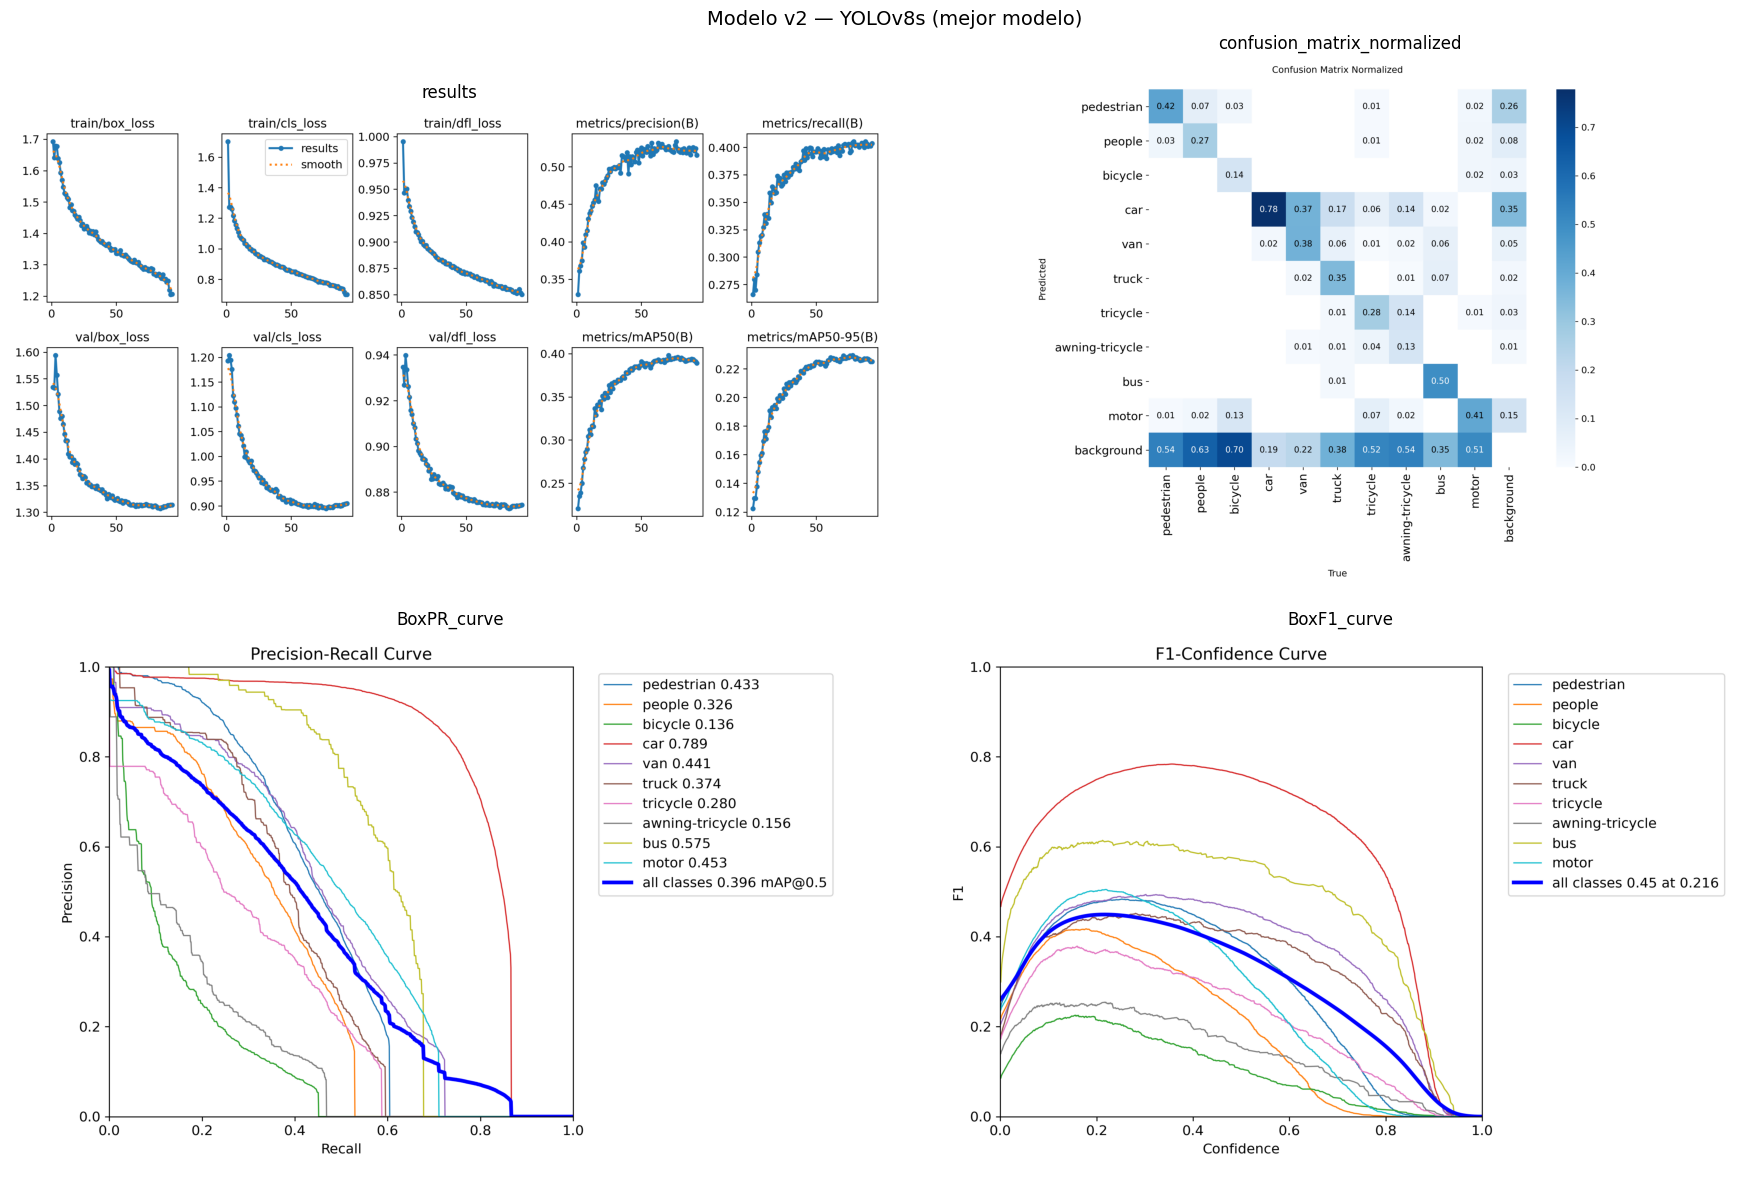

In [40]:
results_dir_v2 = Path('../notebooks/runs/notebooks/runs/models/visdrone_yolov8s_640')

imagenes = ['results.png', 'confusion_matrix_normalized.png', 'BoxPR_curve.png', 'BoxF1_curve.png']
from PIL import Image
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, nombre in enumerate(imagenes):
    img = Image.open(results_dir_v2 / nombre)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(nombre.replace('.png', ''))

plt.suptitle('Modelo v2 — YOLOv8s (mejor modelo)', fontsize=14)
plt.tight_layout()
plt.show()

**Curvas de entrenamiento:** el entrenamiento fue estable y limpio. Las tres losses (box, cls, dfl) descienden consistentemente tanto en train como en val sin divergencia — no hay overfitting. El mAP@0.5 sube de 0.109 en la época 1 hasta 0.396 en la época 78, donde el early stopping detecta que no hay más mejora y para en la 93.

**Matriz de confusión:** car es la clase mejor aprendida con 0.78 en la diagonal — el modelo la detecta correctamente en 3 de cada 4 casos. Las confusiones más frecuentes son con background, especialmente en clases pequeñas como bicycle (0.70 van a background) y awning-tricycle (0.54). Esto confirma el reto principal de VisDrone: objetos tan pequeños que el modelo los pierde contra el fondo.

**Curva Precision-Recall:** car domina claramente con AP 0.789 y una curva muy por encima del resto. Bus (0.575) y motor (0.453) tienen un comportamiento razonable. Bicycle (0.136) y awning-tricycle (0.156) tienen curvas muy bajas — poco datos y objetos pequeños.

**Curva F1-Confidence:** el F1 óptimo global es 0.45 con umbral de confianza 0.216. Esto indica que para maximizar el F1 en producción hay que usar un umbral bajo — el modelo es más útil siendo inclusivo que siendo conservador. Car alcanza F1 cercano a 0.8, muy por encima del resto.

### Demo — Inferencia en vídeos reales urbanos

En esta demo aplicamos el modelo v2 (YOLOv8s entrenado en VisDrone) sobre videos reales de tráfico urbano grabado desde perspectiva aérea. El objetivo es demostrar la viabilidad del sistema en un entorno real, detectando coches, personas y otros vehículos frame a frame y reconstruyendo el vídeo con las predicciones dibujadas encima.

Este tipo de demo representa el caso de uso final del proyecto: un sistema de vigilancia urbana inteligente capaz de procesar vídeo en tiempo real desde cámaras elevadas.

#### Tarea 1 — Inferencia sobre vídeo de tráfico: solo coches

El primer vídeo de prueba muestra una carretera de alta velocidad grabada desde perspectiva aérea. Es el caso más sencillo porque solo aparece una clase, coches, que además es la que mejor detecta nuestro modelo con un mAP@0.5 de 0.724.

El objetivo es verificar que el pipeline de inferencia sobre vídeo funciona correctamente antes de pasar a escenas más complejas con múltiples clases.

En este caso no aplicamos SAHI ya que los coches en una carretera son objetos relativamente grandes y bien visibles. SAHI está pensado para escenas con objetos muy pequeños y alta densidad, como las intersecciones urbanas de VisDrone. Aquí la inferencia estándar es suficiente.

In [ ]:
!yt-dlp -o '../data/video_demo.mp4' 'https://youtu.be/bfc2wsX29zk?si=n4hnf9pBC0FI4Je4'

In [ ]:
DATA_DIR = Path('../data')
video_path = DATA_DIR / 'video_demo.mp4.webm'

model = YOLO('../notebooks/runs/notebooks/runs/models/visdrone_yolov8s_640/weights/best.pt')

print(f"Vídeo existe: {video_path.exists()}")
print(f"Modelo cargado correctamente")

Vídeo existe: True
Modelo cargado correctamente


In [ ]:
cap = cv2.VideoCapture(str(video_path))

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"FPS: {fps}")
print(f"Total frames: {total_frames}")
print(f"Resolución: {width}x{height}")
print(f"Duración: {total_frames/fps:.1f} segundos")

cap.release()

FPS: 59.94006309148265
Total frames: 2836
Resolución: 3840x2160
Duración: 47.3 segundos


In [ ]:
CLASES_VISDRONE = {0: 'pedestrian', 1: 'people', 2: 'bicycle', 3: 'car', 
                   4: 'van', 5: 'truck', 6: 'tricycle', 7: 'awning-tricycle', 
                   8: 'bus', 9: 'motor'}

cap = cv2.VideoCapture(str(video_path))
output_path = DATA_DIR / 'video_demo_output.mp4'

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(str(output_path), fourcc, 30, (3840, 2160))

frame_count = 0
processed = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    # Procesar 1 de cada 2 frames
    if frame_count % 2 == 0:
        results = model.predict(frame, conf=0.3, verbose=False)
        
        for box in results[0].boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            label = f"{CLASES_VISDRONE[cls]} {conf:.2f}"
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 3)
            cv2.putText(frame, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        
        out.write(frame)
        processed += 1
        
        if processed % 50 == 0:
            print(f"Frames procesados: {processed}/{total_frames//2}")
    
    frame_count += 1

cap.release()
out.release()
print("Vídeo guardado en", output_path)

Frames procesados: 50/1418
Frames procesados: 100/1418
Frames procesados: 150/1418
Frames procesados: 200/1418
Frames procesados: 250/1418
Frames procesados: 300/1418
Frames procesados: 350/1418
Frames procesados: 400/1418
Frames procesados: 450/1418
Frames procesados: 500/1418
Frames procesados: 550/1418
Frames procesados: 600/1418
Frames procesados: 650/1418
Frames procesados: 700/1418
Frames procesados: 750/1418
Frames procesados: 800/1418
Frames procesados: 850/1418
Frames procesados: 900/1418
Frames procesados: 950/1418
Frames procesados: 1000/1418
Frames procesados: 1050/1418
Frames procesados: 1100/1418
Frames procesados: 1150/1418
Frames procesados: 1200/1418
Frames procesados: 1250/1418
Frames procesados: 1300/1418
Frames procesados: 1350/1418
Frames procesados: 1400/1418
Vídeo guardado en ../data/video_demo_output.mp4


In [ ]:
!ffmpeg -i '../data/video_demo_output.mp4' -vcodec libx264 '../data/video_demo_h264.mp4' -y

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

In [ ]:
output_h264 = DATA_DIR / 'video_demo_h264.mp4'
Video(str(output_h264), width=800)

El modelo v2 detecta los coches con gran precisión en este vídeo de carretera. Las predicciones son estables frame a frame y los bounding boxes siguen correctamente los vehículos en movimiento, incluso a alta velocidad.

Este resultado es coherente con el mAP@0.5 de 0.724 obtenido para la clase car en el test set: es la clase mejor representada en VisDrone y la que el modelo aprende con más solidez.

En este escenario la inferencia estándar es completamente suficiente. Los coches son objetos grandes y bien visibles desde perspectiva aérea, por lo que SAHI no aportaría mejora significativa.

#### Tarea 2 — Inferencia sobre vídeo de tráfico: múltiples clases

El segundo vídeo añade complejidad al escenario: aparecen camiones, furgonetas y distintos tipos de vehículos además de coches. Esto nos permite evaluar cómo el modelo discrimina entre clases similares como car, van y truck, que visualmente son parecidas desde perspectiva aérea.

En este caso tampoco aplicamos SAHI ya que los vehículos siguen siendo objetos de tamaño considerable. El objetivo es ver si el modelo clasifica correctamente los distintos tipos de vehículos.

In [ ]:
!yt-dlp -o '../data/video_demo2.%(ext)s' 'https://youtu.be/6PhY3SrJk2A?si=8UxRKU_h6vvssb3V'

[youtube] Extracting URL: https://youtu.be/6PhY3SrJk2A?si=8UxRKU_h6vvssb3V
[youtube] 6PhY3SrJk2A: Downloading webpage
[youtube] 6PhY3SrJk2A: Downloading android vr player API JSON
[info] 6PhY3SrJk2A: Downloading 1 format(s): 313+251
[download] Destination: ../data/video_demo2.f313.webm
[download] 100% of   29.69MiB in 00:00:15 at 1.93MiB/s0;33m00:000m
[download] Destination: ../data/video_demo2.f251.webm
[download] 100% of   11.58KiB in 00:00:00 at 51.25KiB/s;33mUnknown
[Merger] Merging formats into "../data/video_demo2.webm"
Deleting original file ../data/video_demo2.f251.webm (pass -k to keep)
Deleting original file ../data/video_demo2.f313.webm (pass -k to keep)


In [ ]:
video_path2 = DATA_DIR / 'video_demo2.webm'

cap = cv2.VideoCapture(str(video_path2))

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"FPS: {fps}")
print(f"Total frames: {total_frames}")
print(f"Resolución: {width}x{height}")
print(f"Duración: {total_frames/fps:.1f} segundos")

cap.release()

FPS: 29.97002997002997
Total frames: 767
Resolución: 3840x2160
Duración: 25.6 segundos


In [ ]:
output_path2 = DATA_DIR / 'video_demo2_output.mp4'

cap = cv2.VideoCapture(str(video_path2))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(str(output_path2), fourcc, 30, (3840, 2160))

frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    results = model.predict(frame, conf=0.3, verbose=False)
    
    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        label = f"{CLASES_VISDRONE[cls]} {conf:.2f}"
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(frame, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
    out.write(frame)
    frame_count += 1
    
    if frame_count % 50 == 0:
        print(f"Frames procesados: {frame_count}/{total_frames}")

cap.release()
out.release()
print("Vídeo guardado")

Frames procesados: 50/767
Frames procesados: 100/767
Frames procesados: 150/767
Frames procesados: 200/767
Frames procesados: 250/767
Frames procesados: 300/767
Frames procesados: 350/767
Frames procesados: 400/767
Frames procesados: 450/767
Frames procesados: 500/767
Frames procesados: 550/767
Frames procesados: 600/767
Frames procesados: 650/767
Frames procesados: 700/767
Frames procesados: 750/767
Vídeo guardado


In [ ]:
!ffmpeg -i '../data/video_demo2_output.mp4' -vcodec libx264 '../data/video_demo2_h264.mp4' -y

output_h264_2 = DATA_DIR / 'video_demo2_h264.mp4'
Video(str(output_h264_2), width=800)

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

El modelo v2 demuestra buena capacidad para discriminar entre clases similares, coches, furgonetas y camiones se detectan correctamente con confianzas altas. El rendimiento es especialmente bueno en zonas de aparcamiento con alta densidad de vehículos.

Los coches en movimiento en la carretera se detectan bien aunque con confianza ligeramente inferior debido al motion blur. Los camiones, al ser una clase menos representada en VisDrone, obtienen confianzas más bajas pero siguen siendo detectados correctamente.

Este vídeo confirma que el modelo generaliza bien a escenas aéreas urbanas reales más allá del dataset de test.

#### Tarea 3 — Inferencia sobre vídeo urbano complejo: personas y vehículos

El tercer vídeo es el más desafiante ya que muestra una intersección urbana concurrida con peatones cruzando y múltiples tipos de vehículos circulando simultáneamente. Es el escenario más cercano al caso de uso real del proyecto.

A diferencia de los vídeos anteriores, aquí sí aplicaremos SAHI además de la inferencia estándar para comparar visualmente si mejora la detección de peatones, que son objetos pequeños y difíciles de detectar desde perspectiva aérea.

In [ ]:
!yt-dlp -o '../data/video_demo3.%(ext)s' 'https://youtu.be/Bqhp2YU8XjU?si=FExN9g-Ko-1PPLbf'

[youtube] Extracting URL: https://youtu.be/Bqhp2YU8XjU?si=FExN9g-Ko-1PPLbf
[youtube] Bqhp2YU8XjU: Downloading webpage
[youtube] Bqhp2YU8XjU: Downloading android vr player API JSON
[info] Bqhp2YU8XjU: Downloading 1 format(s): 137+251
[download] Destination: ../data/video_demo3.f137.mp4
[download] 100% of   23.17MiB in 00:00:06 at 3.74MiB/s0;33m00:000m
[download] Destination: ../data/video_demo3.f251.webm
[download] 100% of  762.99KiB in 00:00:00 at 1.44MiB/s0;33m00:000m
[Merger] Merging formats into "../data/video_demo3.mkv"
Deleting original file ../data/video_demo3.f251.webm (pass -k to keep)
Deleting original file ../data/video_demo3.f137.mp4 (pass -k to keep)


In [ ]:
video_path3 = list(DATA_DIR.glob('video_demo3.*'))[0]
print(f"Archivo: {video_path3.name}")

cap = cv2.VideoCapture(str(video_path3))
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"FPS: {fps}")
print(f"Total frames: {total_frames}")
print(f"Resolución: {width}x{height}")
print(f"Duración: {total_frames/fps:.1f} segundos")
cap.release()

Archivo: video_demo3.mkv
FPS: 29.97002997002997
Total frames: 1405
Resolución: 1920x1080
Duración: 46.9 segundos


In [ ]:
output_path3 = DATA_DIR / 'video_demo3_output.mp4'

cap = cv2.VideoCapture(str(video_path3))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(str(output_path3), fourcc, 30, (1920, 1080))

frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    results = model.predict(frame, conf=0.3, verbose=False)
    
    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        label = f"{CLASES_VISDRONE[cls]} {conf:.2f}"
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    
    out.write(frame)
    frame_count += 1
    
    if frame_count % 50 == 0:
        print(f"Frames procesados: {frame_count}/{total_frames}")

cap.release()
out.release()
print("Vídeo guardado")

Frames procesados: 50/1405
Frames procesados: 100/1405
Frames procesados: 150/1405
Frames procesados: 200/1405
Frames procesados: 250/1405
Frames procesados: 300/1405
Frames procesados: 350/1405
Frames procesados: 400/1405
Frames procesados: 450/1405
Frames procesados: 500/1405
Frames procesados: 550/1405
Frames procesados: 600/1405
Frames procesados: 650/1405
Frames procesados: 700/1405
Frames procesados: 750/1405
Frames procesados: 800/1405
Frames procesados: 850/1405
Frames procesados: 900/1405
Frames procesados: 950/1405
Frames procesados: 1000/1405
Frames procesados: 1050/1405
Frames procesados: 1100/1405
Frames procesados: 1150/1405
Frames procesados: 1200/1405
Frames procesados: 1250/1405
Frames procesados: 1300/1405
Frames procesados: 1350/1405
Frames procesados: 1400/1405
Vídeo guardado


In [ ]:
!ffmpeg -i '../data/video_demo3_output.mp4' -vcodec libx264 '../data/video_demo3_h264.mp4' -y

output_h264_3 = DATA_DIR / 'video_demo3_h264.mp4'
Video(str(output_h264_3), width=800)

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

El tercer vídeo es el más complejo y representativo del caso de uso real. Es una intersección urbana asiática con altísima densidad de tráfico, múltiples tipos de vehículos y peatones cruzando simultáneamente.

El modelo v2 demuestra una capacidad de detección notable en este escenario:

**Lo que funciona bien:**
- Los buses se detectan perfectamente con bounding box muy preciso
- Los coches y furgonetas en zonas más despejadas obtienen confianzas altas (0.73-0.87)
- Los camiones se clasifican correctamente distinguiéndolos de coches y furgonetas
- La clase motor destaca — el modelo detecta correctamente la gran cantidad de motocicletas características de esta escena urbana
- Los peatones aparecen detectados en pasos de cebra y aceras con confianzas entre 0.30 y 0.43, coherente con el mAP@0.5 de 0.278 obtenido en test

**Lo que es más difícil:**
- La zona de alta densidad con cientos de motos solapadas genera confianzas más bajas y algunos bounding boxes se solapan
- Los peatones en zonas muy concurridas no siempre son detectados individualmente por su pequeño tamaño y oclusión

Los tres vídeos demuestran que el modelo v2 generaliza correctamente a escenas urbanas reales muy distintas entre sí — carreteras de alta velocidad, intersecciones mixtas y cruces urbanos densos. Este tercer escenario es donde SAHI aportaría la mayor mejora en producción, reduciendo los fallos en objetos pequeños y zonas de alta densidad.

### Interfaz interactiva de demostración

Interfaz sencilla para probar el modelo v2 sobre imágenes o vídeos propios. Permite subir un archivo, ejecutar la inferencia y visualizar las predicciones directamente en el notebook.

In [43]:
CLASES_VISDRONE = {0: 'pedestrian', 1: 'people', 2: 'bicycle', 3: 'car', 
                   4: 'van', 5: 'truck', 6: 'tricycle', 7: 'awning-tricycle', 
                   8: 'bus', 9: 'motor'}

#  de subida
upload = widgets.FileUpload(accept='.jpg,.jpeg,.png,.mp4,.webm,.mkv', multiple=False)
conf_slider = widgets.FloatSlider(value=0.3, min=0.1, max=0.9, step=0.05, description='Confianza:')
btn_run = widgets.Button(description='Ejecutar inferencia', button_style='success')
output = widgets.Output()

def run_inference(b):
    with output:
        clear_output()
        if not upload.value:
            print("Sube un archivo primero")
            return
        
        #  archivo subido
        file_info = list(upload.value.values())[0]
        ext = Path(file_info['metadata']['name']).suffix.lower()
        tmp = tempfile.NamedTemporaryFile(delete=False, suffix=ext)
        tmp.write(file_info['content'])
        tmp.close()
        
        if ext in ['.jpg', '.jpeg', '.png']:
            #  en imagen
            img = cv2.imread(tmp.name)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            results = model_v2_best.predict(tmp.name, conf=conf_slider.value, verbose=False)
            
            for box in results[0].boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cls = int(box.cls[0])
                conf = float(box.conf[0])
                label = f"{CLASES_VISDRONE[cls]} {conf:.2f}"
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            
            plt.figure(figsize=(14, 8))
            plt.imshow(img)
            plt.axis('off')
            plt.title(f'{len(results[0].boxes)} detecciones')
            plt.show()
            
        elif ext in ['.mp4', '.webm', '.mkv']:
            #  en vídeo
            cap = cv2.VideoCapture(tmp.name)
            total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            fps = cap.get(cv2.CAP_PROP_FPS)
            w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            
            out_path = '/tmp/output_interfaz.mp4'
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            out = cv2.VideoWriter(out_path, fourcc, fps, (w, h))
            
            frame_count = 0
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                results = model_v2_best.predict(frame, conf=conf_slider.value, verbose=False)
                for box in results[0].boxes:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    cls = int(box.cls[0])
                    conf_val = float(box.conf[0])
                    label = f"{CLASES_VISDRONE[cls]} {conf_val:.2f}"
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(frame, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                out.write(frame)
                frame_count += 1
                if frame_count % 30 == 0:
                    print(f"Procesando... {frame_count}/{total} frames")
            
            cap.release()
            out.release()
            
            #  a H264
            h264_path = '/tmp/output_interfaz_h264.mp4'
            os.system(f'ffmpeg -i {out_path} -vcodec libx264 {h264_path} -y -loglevel quiet')
            
            from IPython.display import Video
            display(Video(h264_path, width=800))
        
        os.unlink(tmp.name)

btn_run.on_click(run_inference)

display(widgets.VBox([
    widgets.HTML('<h3> Urban Vision DL — Detector de objetos urbanos</h3>'),
    upload,
    conf_slider,
    btn_run,
    output
]))

## Reflexión profesional

Hemos entrenado un modelo que detecta coches, motos y peatones desde el cielo. Suena genial. Y lo es. Pero antes de desplegar esto en una ciudad real hay cosas que pensar.

### Implicaciones éticas

El sistema detecta personas en el espacio público de forma continua y automática. Los ciudadanos que cruzan una intersección no saben que están siendo clasificados en tiempo real por una red neuronal. Esto choca directamente con el RGPD en Europa. Cualquier despliegue real necesita señalización visible, base legal clara y política de retención de datos definida.

Además un sistema diseñado para gestionar tráfico puede ser reutilizado para seguimiento de individuos o control de manifestaciones. La red no distingue entre usos legítimos e ilegítimos. Esa responsabilidad es de quien opera el sistema, no del modelo.

### Limitaciones del modelo

El modelo tiene claras debilidades que hay que conocer antes de confiar en él ciegamente.

Las clases minoritarias como bicycle y awning-tricycle tienen mAP@0.5 por debajo de 0.15. En producción se perderían la mayoría de estos objetos. VisDrone fue capturado principalmente en ciudades chinas. El modelo puede rendir peor en entornos urbanos europeos o americanos con arquitecturas y tipos de vehículos distintos. Las condiciones de baja iluminación, lluvia o niebla tampoco están bien representadas en el dataset.

### Sesgos potenciales

El sesgo geográfico es el más evidente. Pero también existe sesgo de perspectiva. El modelo fue entrenado principalmente con imágenes aéreas. Aunque añadimos el dataset car+person a nivel de calle, la proporción sigue siendo 6471 imágenes aéreas frente a 3526 de calle. En escenas a nivel de calle el rendimiento puede degradarse.

### Trabajo futuro

Lo que mejoraría esto de verdad es imgsz=1280 con una GPU más potente. Los experimentos mostraron que la resolución es el factor más limitante para objetos pequeños. También añadir datos locales del entorno de despliegue, implementar tracking entre frames para estabilizar las predicciones en vídeo, y explorar SAHI de forma más sistemática con evaluación cuantitativa completa.

### Recomendaciones para un despliegue responsable

Supervisión humana en las alertas generadas, especialmente al principio. Umbral de confianza ajustable por clase. Política clara de acceso y retención de datos. Y A/B testing antes del despliegue completo. Comparar el sistema automático con el operador humano en un subconjunto de cámaras para medir el impacto real.

Este proyecto demuestra que con recursos modestos, una GPU de laptop y datos públicos, se puede construir un sistema de vigilancia urbana funcional. La parte técnica está resuelta. La parte ética, como siempre, es más complicada.